🔍 Correlation between EC-Earth3 and IPSL mean PC1: -0.949
↩️ Flipping IPSL sign to match EC-Earth3 orientation.


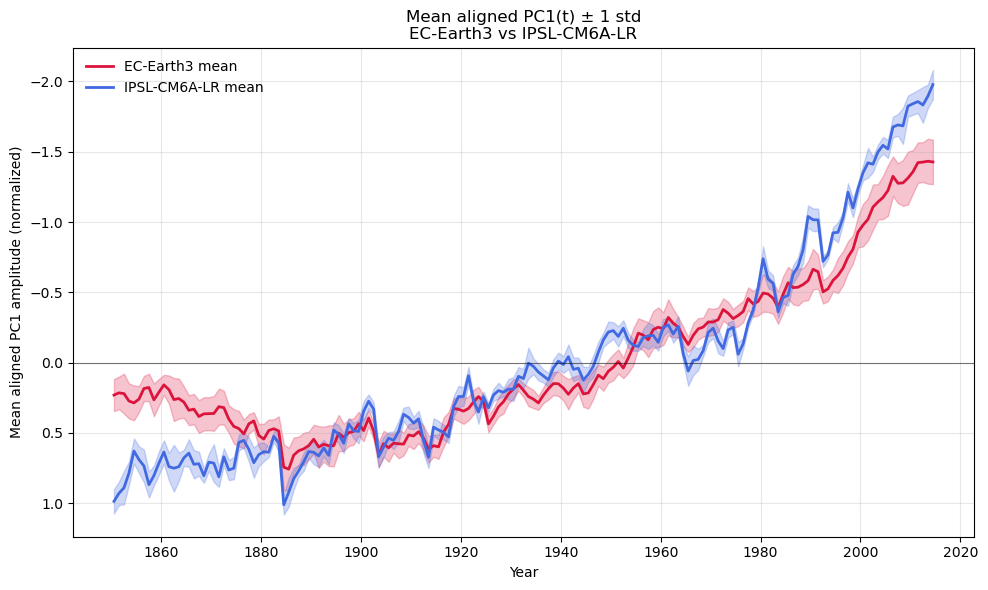

✅ Saved combined figure → /data/users/frekle/EOF/Combined/Mean_PC1_ECearth_vs_IPSL.png


In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os

# =====================================================
# LOAD THE SAVED PC1 PLOTDATA FILES
# =====================================================
ec_file   = "/data/users/frekle/EOF/EC-Earth3/Figures/thetao/Aligned/ECearth3_PC1_plotdata.nc"
ipsl_file = "/data/users/frekle/EOF/IPSL-CM6A-LR/Figures/thetao/Aligned/IPSL_PC1_plotdata.nc"

ds_ec   = xr.open_dataset(ec_file)
ds_ipsl = xr.open_dataset(ipsl_file)

# Extract what we need
ec_time = ds_ec["time"]
ec_mean = ds_ec["pc1_global_mean"]
ec_std  = ds_ec["pc1_global_std"]

ipsl_time = ds_ipsl["time"]
ipsl_mean = ds_ipsl["pc1_global_mean"]
ipsl_std  = ds_ipsl["pc1_global_std"]

# Align both on a common time base
common_time = np.intersect1d(ec_time, ipsl_time)

ec_mean = ec_mean.sel(time=common_time)
ec_std  = ec_std.sel(time=common_time)
ipsl_mean = ipsl_mean.sel(time=common_time)
ipsl_std  = ipsl_std.sel(time=common_time)

# =====================================================
# ENSURE BOTH MODELS HAVE THE SAME SIGN ORIENTATION
# =====================================================

# Compute correlation between EC and IPSL mean PC1(t)
corr = np.corrcoef(ec_mean, ipsl_mean)[0, 1]
print(f"🔍 Correlation between EC-Earth3 and IPSL mean PC1: {corr:.3f}")

# Flip IPSL if anticorrelated (mirrored)
if corr < 0:
    print("↩️ Flipping IPSL sign to match EC-Earth3 orientation.")
    ipsl_mean *= -1
    ipsl_std  *= -1   # keep std symmetric around 0
else:
    print("✅ IPSL already aligned with EC-Earth3 orientation.")


# Plot combined figure

fig, ax = plt.subplots(figsize=(10,6))

# EC-Earth3 (red)
ax.plot(common_time, ec_mean, color="crimson", lw=2, label="EC-Earth3 mean")
ax.fill_between(common_time, ec_mean-ec_std, ec_mean+ec_std,
                color="crimson", alpha=0.25)

# IPSL-CM6A-LR (blue)
ax.plot(common_time, ipsl_mean, color="royalblue", lw=2, label="IPSL-CM6A-LR mean")
ax.fill_between(common_time, ipsl_mean-ipsl_std, ipsl_mean+ipsl_std,
                color="royalblue", alpha=0.25)

# Style
ax.axhline(0, color="black", lw=0.8, alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Mean aligned PC1 amplitude (normalized)")
ax.set_title("Mean aligned PC1(t) ± 1 std\nEC-Earth3 vs IPSL-CM6A-LR")
ax.legend(frameon=False)
ax.grid(alpha=0.3)

# Reverse vertical orientation
ax.invert_yaxis()

plt.tight_layout()

# Save
outpath = "/data/users/frekle/EOF/Combined/Mean_PC1_ECearth_vs_IPSL.png"
os.makedirs(os.path.dirname(outpath), exist_ok=True)
plt.savefig(outpath, dpi=300)
plt.show()

print(f"✅ Saved combined figure → {outpath}")




Loaded members: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 24]


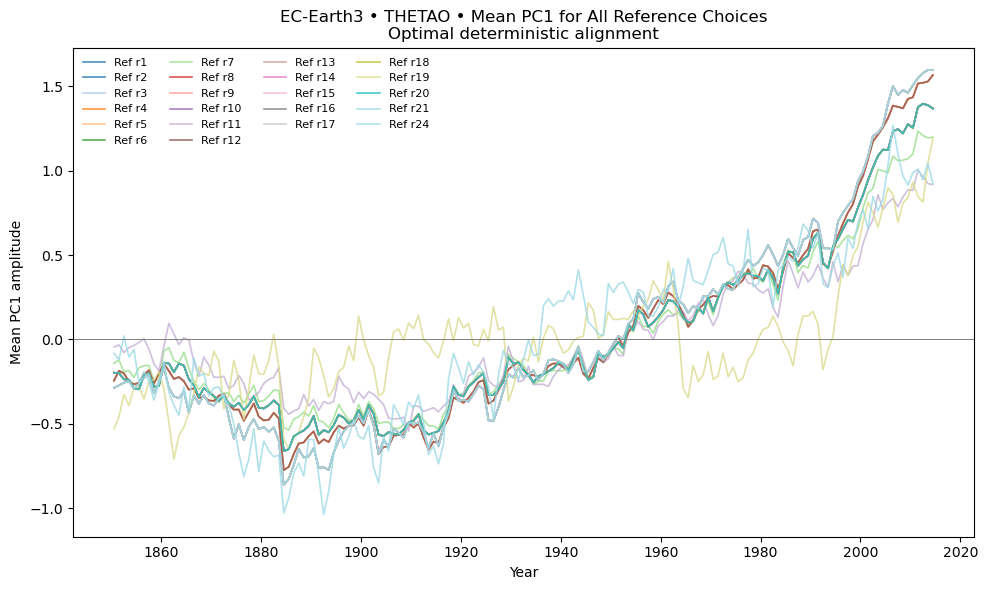

In [4]:
#!/usr/bin/env python3
# =====================================================
# UNIVERSAL EOF ALIGNMENT SCRIPT – Optimal Method
# Works for EC-Earth3, IPSL-CM6A-LR, CESM2
# Deterministic alignment + global sign + trend enforcement
# Freja Klejnstrup · DMI/AU · 2025
# =====================================================

import xarray as xr
import numpy as np
import glob
import re
import os
import matplotlib.pyplot as plt

# =====================================================
# CONFIG
# =====================================================
MODEL = "EC-Earth3"    # ← CHANGE HERE
VAR   = "thetao"           # ← CHANGE HERE
TOP_MODES = 3              # Plot & align modes 1–3

IN_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/"

# =====================================================
# FUNCTIONS
# =====================================================
def pattern_corr(a, b):
    """Spatial Pearson correlation between two EOF patterns."""
    av, bv = a.values.flatten(), b.values.flatten()
    mask = np.isfinite(av) & np.isfinite(bv)
    if mask.sum() < 3:
        return np.nan
    av = av[mask] - av[mask].mean()
    bv = bv[mask] - bv[mask].mean()
    return float(np.dot(av, bv) / (np.sqrt((av*av).sum()) * np.sqrt((bv*bv).sum())))


def deterministic_align(ref_eofs, mem_eofs, topmodes=TOP_MODES):
    """
    Optimal alignment:
      • Build full correlation matrix (ref_modes x all_mem_modes)
      • For each ref mode i: choose j = argmax(|corr[i,:]|)
      • Apply sign flip so corr[i,j] > 0
    """
    nref = ref_eofs.sizes["mode"]
    nmem = mem_eofs.sizes["mode"]

    corr_mat = np.zeros((topmodes, nmem))

    for i in range(topmodes):
        for j in range(nmem):
            corr_mat[i, j] = pattern_corr(ref_eofs.isel(mode=i), mem_eofs.isel(mode=j))

    mapping = {i: int(np.nanargmax(np.abs(corr_mat[i, :]))) for i in range(topmodes)}

    aligned = []
    for i in range(topmodes):
        j = mapping[i]
        sign = 1 if corr_mat[i, j] >= 0 else -1
        aligned.append(mem_eofs.isel(mode=j) * sign)

    aligned = xr.concat(aligned, dim="mode")
    aligned = aligned.assign_coords(mode=np.arange(1, topmodes + 1))

    return aligned, mapping


# =====================================================
# LOAD RAW EOF/PC FILES
# =====================================================
pattern = f"EOF_{VAR}_r*i1p1f1.nc"
files = sorted(glob.glob(os.path.join(IN_DIR, pattern)))
if not files:
    raise FileNotFoundError("No raw EOF files found!")

members = []
eofs_all = {}
pcs_all  = {}

for f in files:
    fname = os.path.basename(f)
    m = re.search(r"_r(\d+)i1p1f1", fname)
    if not m:
        continue
    member = int(m.group(1))

    ds = xr.open_dataset(f)
    eofs_all[member] = ds["EOFs"]    # ALL modes (important)
    pcs_all[member]  = ds["PCs"]     # ALL modes
    members.append(member)

members = sorted(members)
print("Loaded members:", members)

time = pcs_all[members[0]].time
years = time.dt.year
colors = plt.cm.tab20(np.linspace(0, 1, len(members)))

# =====================================================
# REFERENCE-SENSITIVITY ANALYSIS (UNIVERSAL + OPTIMAL)
# =====================================================
plt.figure(figsize=(10, 6))

reference_1 = members[0]
ref1_pc1_mean = None
all_pc1_means = []

for idx, ref in enumerate(members):

    ref_eofs = eofs_all[ref]
    aligned_pc1_list = []

    for mem in members:
        mem_eofs = eofs_all[mem]
        mem_pcs  = pcs_all[mem]

        if mem == ref:
            aligned_pc1 = mem_pcs.isel(mode=0)
        else:
            aligned_eofs, mapping = deterministic_align(ref_eofs, mem_eofs)
            j = mapping[0]
            corr = pattern_corr(ref_eofs.isel(mode=0), mem_eofs.isel(mode=j))
            sign = 1 if corr >= 0 else -1
            aligned_pc1 = mem_pcs.isel(mode=j) * sign

        aligned_pc1_list.append(aligned_pc1)

    stack = xr.concat(aligned_pc1_list, dim="member")
    pc1_mean = stack.mean("member")

    # Global sign enforcement
    if ref == reference_1:
        ref1_pc1_mean = pc1_mean
    else:
        corr_to_ref1 = np.corrcoef(
            pc1_mean.values,
            ref1_pc1_mean.values
        )[0, 1]
        if corr_to_ref1 < 0:
            pc1_mean = pc1_mean * -1

    # Trend-direction enforcement
    t = np.arange(pc1_mean.size)
    slope = np.polyfit(t, pc1_mean.values, 1)[0]
    if slope < 0:
        pc1_mean = pc1_mean * -1

    all_pc1_means.append(pc1_mean)

    plt.plot(pc1_mean["time"], pc1_mean,
             color=colors[idx], lw=1.2, alpha=0.8,
             label=f"Ref r{ref}")

plt.axhline(0, color="gray", lw=0.7)
plt.title(f"{MODEL} • {VAR.upper()} • Mean PC1 for All Reference Choices\nOptimal deterministic alignment")
plt.xlabel("Year")
plt.ylabel("Mean PC1 amplitude")
plt.legend(ncol=4, fontsize=8, frameon=False)
plt.tight_layout()
plt.show()


In [13]:
#!/usr/bin/env python3
# =====================================================
# UNIVERSAL EOF ALIGNMENT SCRIPT – Optimal Method
# Saves aligned EOFs and aligned PCs to disk
# Freja Klejnstrup · DMI/AU · 2025
# =====================================================

import xarray as xr
import numpy as np
import glob
import re
import os
import matplotlib.pyplot as plt

# =====================================================
# CONFIG
# =====================================================
MODEL = "CESM2"    # ← CHANGE HERE
VAR   = "thetao"           # ← CHANGE HERE
TOP_MODES = 3              # Align first 3 modes

IN_DIR  = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/{VAR}/"
OUT_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/{VAR}/aligned/"
os.makedirs(OUT_DIR, exist_ok=True)

# =====================================================
# FUNCTIONS
# =====================================================
def pattern_corr(a, b):
    """Spatial Pearson correlation between two EOF patterns."""
    av, bv = a.values.flatten(), b.values.flatten()
    mask = np.isfinite(av) & np.isfinite(bv)
    if mask.sum() < 3:
        return np.nan
    av = av[mask] - av[mask].mean()
    bv = bv[mask] - bv[mask].mean()
    return float(np.dot(av, bv) /
                 (np.sqrt((av*av).sum()) * np.sqrt((bv*bv).sum())))


def deterministic_align(ref_eofs, mem_eofs, topmodes=TOP_MODES):
    """Optimal deterministic alignment."""
    nm = mem_eofs.sizes["mode"]
    corr_mat = np.zeros((topmodes, nm))

    for i in range(topmodes):
        for j in range(nm):
            corr_mat[i, j] = pattern_corr(ref_eofs.isel(mode=i),
                                          mem_eofs.isel(mode=j))

    mapping = {i: int(np.nanargmax(np.abs(corr_mat[i, :])))
               for i in range(topmodes)}

    aligned = []
    for i in range(topmodes):
        j = mapping[i]
        sign = 1 if corr_mat[i, j] >= 0 else -1
        aligned.append(mem_eofs.isel(mode=j) * sign)

    aligned = xr.concat(aligned, dim="mode").assign_coords(
        mode=np.arange(1, topmodes+1)
    )
    return aligned, mapping


# =====================================================
# LOAD RAW EOF/PC FILES
# =====================================================
pattern = f"EOF_{VAR}_r*i1p1f1.nc"
files = sorted(glob.glob(os.path.join(IN_DIR, pattern)))
if not files:
    raise FileNotFoundError("No raw EOF files found!")

members = []
eofs_all = {}
pcs_all  = {}

for f in files:
    fname = os.path.basename(f)
    m = re.search(r"_r(\d+)i1p1f1", fname)
    if not m:
        continue
    member = int(m.group(1))

    ds = xr.open_dataset(f)
    eofs_all[member] = ds["eofs_corr"]     # all modes
    pcs_all[member]  = ds["pcs"]      # all modes
    members.append(member)

members = sorted(members)
print("Loaded members:", members)


# =====================================================
# ALIGN + SAVE ALIGNED FILES
# =====================================================

reference = members[0]
ref_eofs = eofs_all[reference]

print(f"\nUsing r{reference} as reference alignment member\n")

for mem in members:
    print(f"Aligning member r{mem}...")

    raw_eofs = eofs_all[mem]
    raw_pcs  = pcs_all[mem]

    if mem == reference:
        aligned_eofs = raw_eofs.isel(mode=slice(0, TOP_MODES))
        aligned_pcs  = raw_pcs.isel(mode=slice(0, TOP_MODES))

    else:
        aligned_eofs, mapping = deterministic_align(ref_eofs, raw_eofs)

        pcs_list = []
        for i in range(TOP_MODES):
            j = mapping[i]
            corr = pattern_corr(ref_eofs.isel(mode=i), raw_eofs.isel(mode=j))
            sign = 1 if corr >= 0 else -1
            pcs_list.append(raw_pcs.isel(mode=j) * sign)

        aligned_pcs = xr.concat(pcs_list, dim="mode").assign_coords(
            mode=np.arange(1, TOP_MODES+1)
        )

    # --- recompute variance fraction for aligned PCs ---
    pcs_vals = aligned_pcs.transpose("time", "mode").values   # (time, mode)
    lambdas  = np.var(pcs_vals, axis=0, ddof=1)               # (mode,)
    variance_fraction = lambdas / np.sum(lambdas)

    aligned_variance = xr.DataArray(
        variance_fraction,
        dims=("mode",),
        coords={"mode": np.arange(1, TOP_MODES+1)},
        name="aligned_variance_fraction"
    )

    # --- build dataset ---
    aligned_ds = xr.Dataset(
        {
            "aligned_eofs": aligned_eofs,
            "aligned_pcs": aligned_pcs,
            "aligned_variance_fraction": aligned_variance,
        },
        coords={
            "mode": np.arange(1, TOP_MODES+1),
            "time": aligned_pcs.time,
            "lat": aligned_eofs.lat,
            "lon": aligned_eofs.lon,
        }   
    )


    outfile = f"{OUT_DIR}/EOF_{VAR}_r{mem}i1p1f1_aligned.nc"
    aligned_ds.to_netcdf(outfile)

    print(f" ✓ Saved {outfile}")

print("\n🎉 All aligned EOF/PC files saved!")


Loaded members: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Using r1 as reference alignment member

Aligning member r1...
 ✓ Saved /data/projects/nckf/frekle/EOF_results/CESM2/thetao/aligned//EOF_thetao_r1i1p1f1_aligned.nc
Aligning member r2...
 ✓ Saved /data/projects/nckf/frekle/EOF_results/CESM2/thetao/aligned//EOF_thetao_r2i1p1f1_aligned.nc
Aligning member r3...
 ✓ Saved /data/projects/nckf/frekle/EOF_results/CESM2/thetao/aligned//EOF_thetao_r3i1p1f1_aligned.nc
Aligning member r4...
 ✓ Saved /data/projects/nckf/frekle/EOF_results/CESM2/thetao/aligned//EOF_thetao_r4i1p1f1_aligned.nc
Aligning member r5...
 ✓ Saved /data/projects/nckf/frekle/EOF_results/CESM2/thetao/aligned//EOF_thetao_r5i1p1f1_aligned.nc
Aligning member r6...
 ✓ Saved /data/projects/nckf/frekle/EOF_results/CESM2/thetao/aligned//EOF_thetao_r6i1p1f1_aligned.nc
Aligning member r7...
 ✓ Saved /data/projects/nckf/frekle/EOF_results/CESM2/thetao/aligned//EOF_thetao_r7i1p1f1_aligned.nc
Aligning member r8...
 ✓ Saved /data/projects/nckf

Loaded members: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


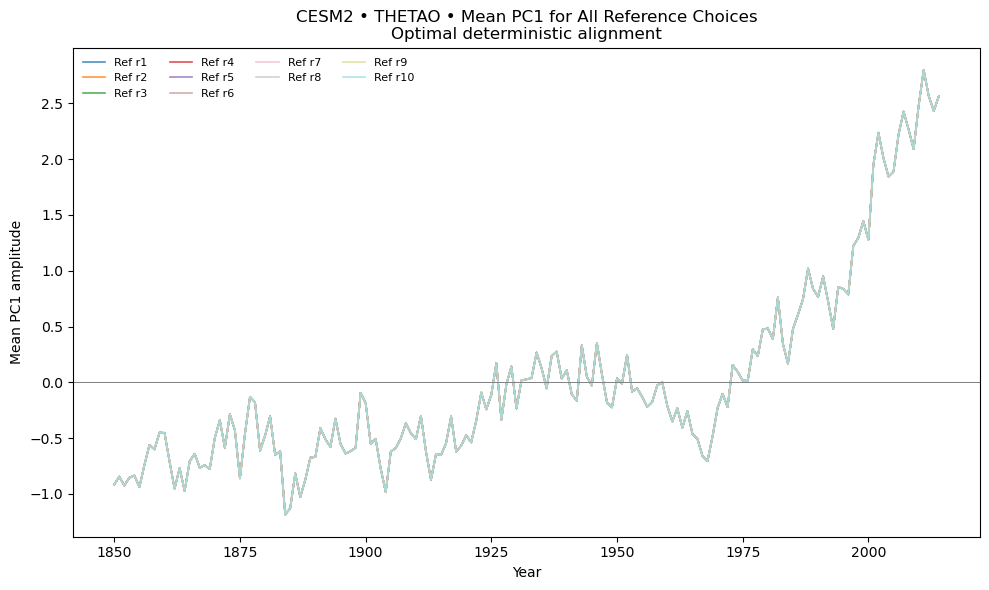

In [10]:
#!/usr/bin/env python3
# =====================================================
# UNIVERSAL EOF ALIGNMENT SCRIPT – Optimal Method
# Works for EC-Earth3, IPSL-CM6A-LR, CESM2
# Deterministic alignment + global sign + trend enforcement
# Freja Klejnstrup · DMI/AU · 2025
# =====================================================

import xarray as xr
import numpy as np
import glob
import re
import os
import matplotlib.pyplot as plt

# =====================================================
# CONFIG
# =====================================================
MODEL = "CESM2"    # ← CHANGE HERE
VAR   = "thetao"           # ← CHANGE HERE
TOP_MODES = 3              # Plot & align modes 1–3

IN_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/{VAR}/"

# =====================================================
# FUNCTIONS
# =====================================================
def pattern_corr(a, b):
    """Spatial Pearson correlation between two EOF patterns."""
    av, bv = a.values.flatten(), b.values.flatten()
    mask = np.isfinite(av) & np.isfinite(bv)
    if mask.sum() < 3:
        return np.nan
    av = av[mask] - av[mask].mean()
    bv = bv[mask] - bv[mask].mean()
    return float(np.dot(av, bv) / (np.sqrt((av*av).sum()) * np.sqrt((bv*bv).sum())))


def deterministic_align(ref_eofs, mem_eofs, topmodes=TOP_MODES):
    """
    Optimal alignment:
      • Build full correlation matrix (ref_modes x all_mem_modes)
      • For each ref mode i: choose j = argmax(|corr[i,:]|)
      • Apply sign flip so corr[i,j] > 0
    """
    nref = ref_eofs.sizes["mode"]
    nmem = mem_eofs.sizes["mode"]

    corr_mat = np.zeros((topmodes, nmem))

    for i in range(topmodes):
        for j in range(nmem):
            corr_mat[i, j] = pattern_corr(ref_eofs.isel(mode=i), mem_eofs.isel(mode=j))

    mapping = {i: int(np.nanargmax(np.abs(corr_mat[i, :]))) for i in range(topmodes)}

    aligned = []
    for i in range(topmodes):
        j = mapping[i]
        sign = 1 if corr_mat[i, j] >= 0 else -1
        aligned.append(mem_eofs.isel(mode=j) * sign)

    aligned = xr.concat(aligned, dim="mode")
    aligned = aligned.assign_coords(mode=np.arange(1, topmodes + 1))

    return aligned, mapping


# =====================================================
# LOAD RAW EOF/PC FILES
# =====================================================
pattern = f"EOF_{VAR}_r*i1p1f1.nc"
files = sorted(glob.glob(os.path.join(IN_DIR, pattern)))
if not files:
    raise FileNotFoundError("No raw EOF files found!")

members = []
eofs_all = {}
pcs_all  = {}

for f in files:
    fname = os.path.basename(f)
    m = re.search(r"_r(\d+)i1p1f1", fname)
    if not m:
        continue
    member = int(m.group(1))

    ds = xr.open_dataset(f)
    eofs_all[member] = ds["eofs_corr"]    # ALL modes (important)
    pcs_all[member]  = ds["pcs"]     # ALL modes
    members.append(member)

members = sorted(members)
print("Loaded members:", members)

time = pcs_all[members[0]].time
years = time.dt.year
colors = plt.cm.tab20(np.linspace(0, 1, len(members)))

# =====================================================
# REFERENCE-SENSITIVITY ANALYSIS (UNIVERSAL + OPTIMAL)
# =====================================================
plt.figure(figsize=(10, 6))

reference_1 = members[0]
ref1_pc1_mean = None
all_pc1_means = []

for idx, ref in enumerate(members):

    ref_eofs = eofs_all[ref]
    aligned_pc1_list = []

    for mem in members:
        mem_eofs = eofs_all[mem]
        mem_pcs  = pcs_all[mem]

        if mem == ref:
            aligned_pc1 = mem_pcs.isel(mode=0)
        else:
            aligned_eofs, mapping = deterministic_align(ref_eofs, mem_eofs)
            j = mapping[0]
            corr = pattern_corr(ref_eofs.isel(mode=0), mem_eofs.isel(mode=j))
            sign = 1 if corr >= 0 else -1
            aligned_pc1 = mem_pcs.isel(mode=j) * sign

        aligned_pc1_list.append(aligned_pc1)

    stack = xr.concat(aligned_pc1_list, dim="member")
    pc1_mean = stack.mean("member")

    # Global sign enforcement
    if ref == reference_1:
        ref1_pc1_mean = pc1_mean
    else:
        corr_to_ref1 = np.corrcoef(
            pc1_mean.values,
            ref1_pc1_mean.values
        )[0, 1]
        if corr_to_ref1 < 0:
            pc1_mean = pc1_mean * -1

    # Trend-direction enforcement
    t = np.arange(pc1_mean.size)
    slope = np.polyfit(t, pc1_mean.values, 1)[0]
    if slope < 0:
        pc1_mean = pc1_mean * -1

    all_pc1_means.append(pc1_mean)

    # Convert CESM2 cftime to numeric years
    years = pc1_mean["time"].dt.year.astype(float)

    plt.plot(years, pc1_mean,
            color=colors[idx], lw=1.2, alpha=0.8,
            label=f"Ref r{ref}")


plt.axhline(0, color="gray", lw=0.7)
plt.title(f"{MODEL} • {VAR.upper()} • Mean PC1 for All Reference Choices\nOptimal deterministic alignment")
plt.xlabel("Year")
plt.ylabel("Mean PC1 amplitude")
plt.legend(ncol=4, fontsize=8, frameon=False)
plt.tight_layout()
plt.show()


 → Flipping sign for EC-Earth3 (corr=-0.89)
 → IPSL-CM6A-LR already aligned with CESM2 (corr=0.94)


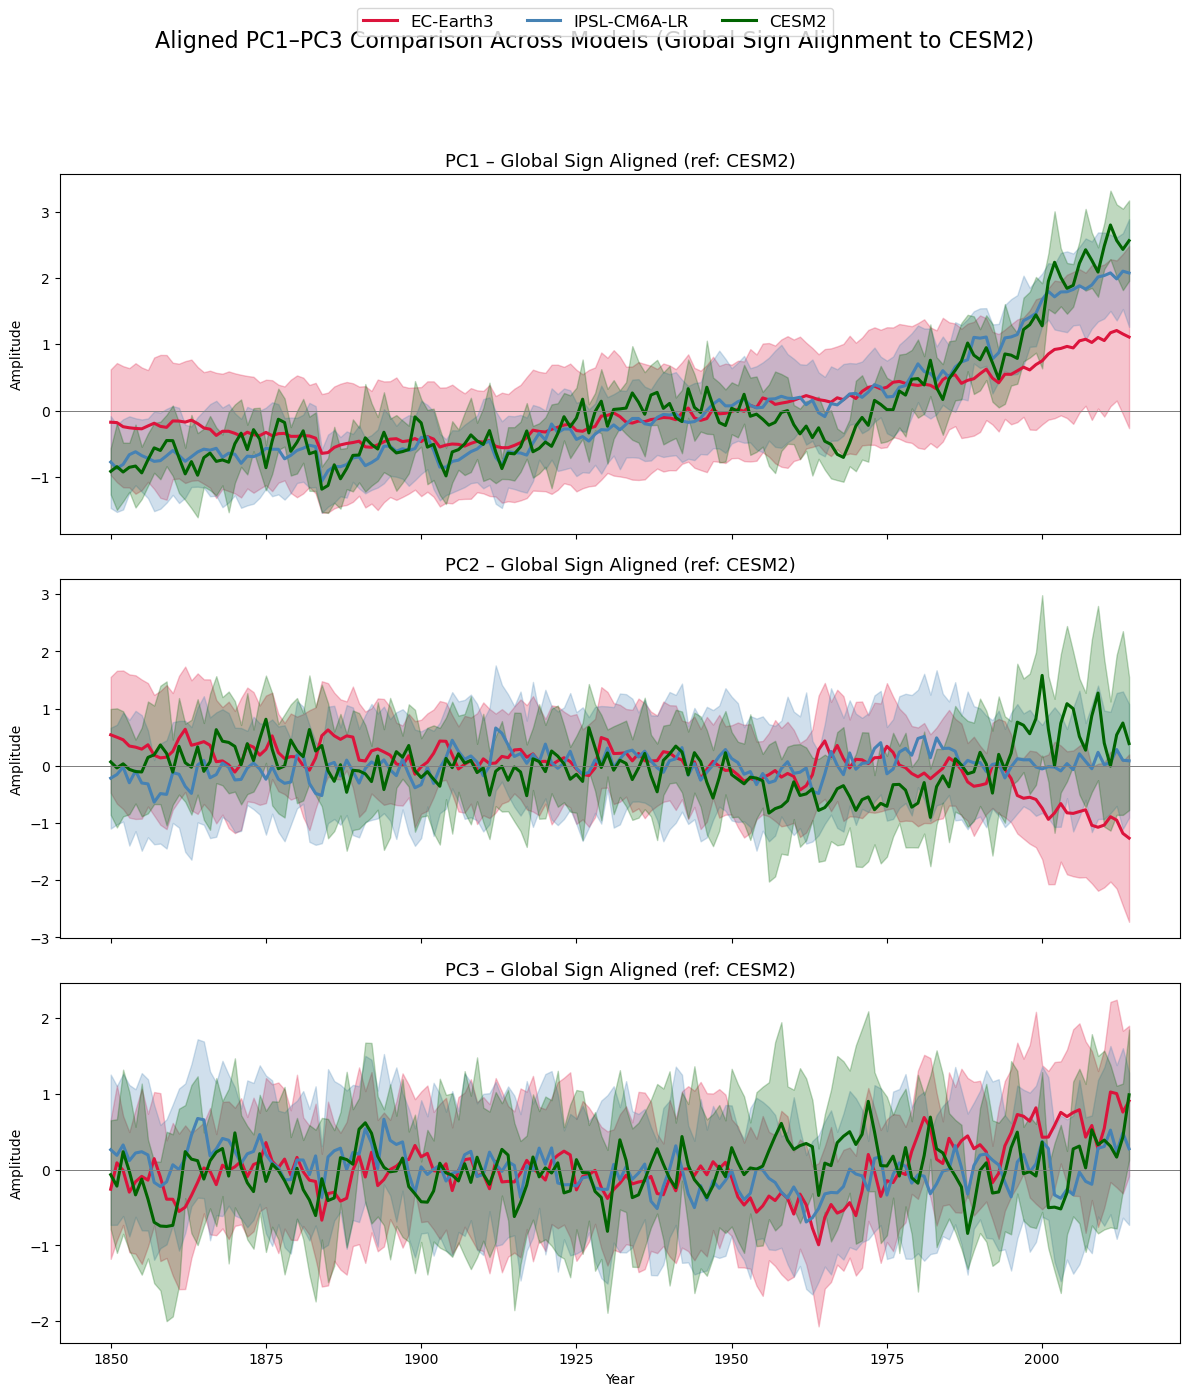

In [6]:
#!/usr/bin/env python3
# ======================================================================
# Combined comparison plot for PC1–PC3 from ALIGNED files
# GLOBAL SIGN ALIGNMENT: CESM2 is the reference model
# ======================================================================

import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ---------------------------
# CONFIG
# ---------------------------
VAR = "thetao"
MODELS = ["EC-Earth3", "IPSL-CM6A-LR", "CESM2"]
TOP_MODES = 3

ALIGNED_DIR = {
    "EC-Earth3":     "/data/projects/nckf/frekle/EOF_results/EC-Earth3/aligned/",
    "IPSL-CM6A-LR":  "/data/projects/nckf/frekle/EOF_results/IPSL-CM6A-LR/thetao/aligned/",
    "CESM2":         "/data/projects/nckf/frekle/EOF_results/CESM2/thetao/aligned/",
}

MODEL_COLORS = {
    "EC-Earth3":     "crimson",
    "IPSL-CM6A-LR":  "steelblue",
    "CESM2":         "darkgreen",
}

GLOBAL_REF = "CESM2"   # <<–––––––––––– YOU CHOSE THIS


# ---------------------------
# FUNCTION: Load aligned PCs
# ---------------------------
def load_aligned_model(model):

    files = sorted(glob.glob(os.path.join(ALIGNED_DIR[model],
                                          f"EOF_{VAR}_r*i1p1f1_aligned.nc")))
    if not files:
        raise FileNotFoundError(f"No aligned files found for {model}")

    pcs_list = []
    for f in files:
        ds = xr.open_dataset(f)
        pcs_list.append(ds["aligned_pcs"])   # (time, mode)

    time = pcs_list[0].time
    years = time.dt.year.astype(float)

    pcs_stack = xr.concat(pcs_list, dim="member")   # (member, time, mode)

    return pcs_stack, years


# ============================================================
# LOAD ALL MODELS FIRST – so we can align signs globally
# ============================================================
all_models_pcs = {}
all_models_years = {}

for model in MODELS:
    pcs_stack, years = load_aligned_model(model)
    all_models_pcs[model] = pcs_stack
    all_models_years[model] = years

# ============================================================
# GLOBAL SIGN ALIGNMENT TO CESM2
# ============================================================
ref_pc1 = all_models_pcs[GLOBAL_REF].isel(mode=0).mean("member")

for model in MODELS:
    if model == GLOBAL_REF:
        continue

    model_pc1 = all_models_pcs[model].isel(mode=0).mean("member")

    corr = np.corrcoef(ref_pc1.values, model_pc1.values)[0, 1]

    if corr < 0:
        print(f" → Flipping sign for {model} (corr={corr:.2f})")
        all_models_pcs[model] = all_models_pcs[model] * -1
    else:
        print(f" → {model} already aligned with CESM2 (corr={corr:.2f})")


# ============================================================
# PLOTTING
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

for model in MODELS:

    pcs_stack = all_models_pcs[model]
    years = all_models_years[model]

    for mode in range(TOP_MODES):
        ax = axes[mode]

        pc = pcs_stack.isel(mode=mode)   # (member, time)
        mean_pc = pc.mean("member")
        std_pc  = pc.std("member")

        col = MODEL_COLORS[model]

        ax.plot(years, mean_pc, lw=2.2, color=col, label=model)
        ax.fill_between(years,
                        mean_pc - std_pc,
                        mean_pc + std_pc,
                        color=col, alpha=0.25)

        ax.axhline(0, color="gray", lw=0.6)
        ax.set_title(f"PC{mode+1} – Global Sign Aligned (ref: CESM2)", fontsize=13)
        ax.set_ylabel("Amplitude")

axes[-1].set_xlabel("Year")

# ---------------------------
# SAFE LEGEND
# ---------------------------
handles, labels = fig.gca().get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=12)


fig.suptitle("Aligned PC1–PC3 Comparison Across Models (Global Sign Alignment to CESM2)", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.93])
plt.show()


### Combined member EOF

#### Old

In [10]:
#!/usr/bin/env python3
# ======================================================================
# SCRIPT 1 — Combined EOF for ALL members (curvilinear or regular grid)
# With progress printing
# ======================================================================

import os
import glob
import numpy as np
import xarray as xr
from eofs.standard import Eof
import warnings
warnings.filterwarnings("ignore")

# ============================
# CONFIG
# ============================
MODEL = "CESM2"     # ← CHANGE HERE
VAR   = "thetao"         # ← CHANGE HERE
NMODES = 50

IN_DIR  = f"/data/projects/nckf/frekle/CMIP6_data/{MODEL}/{VAR}/masked/"
OUT_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined/"
os.makedirs(OUT_DIR, exist_ok=True)

# ============================
# Helper: universal lat/lon finder
# ============================
def find_lat_lon(ds):
    """Return 2D lat, lon arrays regardless of naming."""
    for latname in ["lat", "latitude", "nav_lat"]:
        if latname in ds:
            lat = ds[latname]
            break
    else:
        raise KeyError("No latitude found.")

    for lonname in ["lon", "longitude", "nav_lon"]:
        if lonname in ds:
            lon = ds[lonname]
            break
    else:
        raise KeyError("No longitude found.")

    # 1D → broadcast to 2D
    if lat.ndim == 1 and lon.ndim == 1:
        print("→ Detected 1D lat/lon (rectangular grid) — broadcasting to 2D")
        lon2d, lat2d = np.meshgrid(lon.values, lat.values)
        return xr.DataArray(lat2d, dims=("lat", "lon")), xr.DataArray(lon2d, dims=("lat", "lon"))

    print("→ Detected 2D curvilinear grid")
    return lat, lon


# ============================
# LOAD ALL MEMBERS & STACK
# ============================
files = sorted(glob.glob(os.path.join(IN_DIR, f"{VAR}_masked_r*i1p1f1*.nc")))
if not files:
    raise FileNotFoundError("No masked files found!")

print(f"\n📂 Found {len(files)} members for {MODEL}\n")

anom_list = []
lat2d = lon2d = None

for idx, f in enumerate(files, start=1):
    print(f"→ Loading member {idx}/{len(files)}: {os.path.basename(f)}")
    ds = xr.open_dataset(f)
    da = ds[VAR]

    # surface level
    if "lev" in da.dims or "olevel" in da.dims:
        da = da.isel({d: 0 for d in da.dims if d in ["lev", "olevel"]})

    if lat2d is None:
        lat2d, lon2d = find_lat_lon(ds)

    print(f"   computing anomaly…")
    anom = da - da.mean("time")
    anom_list.append(anom)


print("\n🧱 Stacking all members into one large dataset…")
combined = xr.concat(anom_list, dim="time")
combined["time"] = np.arange(combined.sizes["time"])  # reset time index

# Identify spatial dims
spatial_dims = combined.dims[-2:]   # works for both (lat,lon) and (j,i)
ny, nx = combined.sizes[spatial_dims[-2]], combined.sizes[spatial_dims[-1]]
space_size = ny * nx

# Flatten to (samples, space)
print(f"→ Flattening to shape ({combined.sizes['time']} samples, {space_size} space)…")
data2d = combined.values.reshape(combined.sizes["time"], space_size)
data2d = np.ma.masked_invalid(data2d)

# ============================
# WEIGHTS
# ============================
print("→ Computing weights…")
if "areacello" in ds:
    print("   using areacello")
    weights = np.sqrt(ds["areacello"].values.reshape(space_size))
else:
    print("   using cos(lat) weights")
    weights = np.sqrt(np.cos(np.deg2rad(lat2d.values)).reshape(space_size))

# ============================
# EOF SOLVER
# ============================
print("\n🚀 Running EOF solver… this may take a while…")
solver = Eof(data2d, weights=weights)

print("→ Extracting EOFs, PCs, variance fractions…")
eofs_flat = solver.eofs(neofs=NMODES)
pcs       = solver.pcs(npcs=NMODES)
vf        = solver.varianceFraction()[0:NMODES]

# Unflatten EOF maps
print("→ Unflattening EOF maps…")
eofs_map = eofs_flat.reshape(NMODES, ny, nx)

# ============================
# SAVE OUTPUT
# ============================
outfile = os.path.join(OUT_DIR, f"EOF_combined_{VAR}.nc")
print(f"\n💾 Saving combined EOF dataset to:")
print(f"   {outfile}")

ds_out = xr.Dataset({
    "EOF": (("mode","y","x"), eofs_map),
    "PC":  (("time","mode"), pcs),
    "variance_fraction": (("mode",), vf),
    "lat": lat2d,
    "lon": lon2d,
})
ds_out["mode"] = np.arange(1, NMODES+1)

ds_out.to_netcdf(outfile)

print("\n🎉 DONE! Combined EOF successfully saved.")



📂 Found 10 members for CESM2

→ Loading member 1/10: thetao_masked_r10i1p1f1.nc
→ Detected 2D curvilinear grid
   computing anomaly…
→ Loading member 2/10: thetao_masked_r1i1p1f1.nc
   computing anomaly…
→ Loading member 3/10: thetao_masked_r2i1p1f1.nc
   computing anomaly…
→ Loading member 4/10: thetao_masked_r3i1p1f1.nc
   computing anomaly…
→ Loading member 5/10: thetao_masked_r4i1p1f1.nc
   computing anomaly…
→ Loading member 6/10: thetao_masked_r5i1p1f1.nc
   computing anomaly…
→ Loading member 7/10: thetao_masked_r6i1p1f1.nc
   computing anomaly…
→ Loading member 8/10: thetao_masked_r7i1p1f1.nc
   computing anomaly…
→ Loading member 9/10: thetao_masked_r8i1p1f1.nc
   computing anomaly…
→ Loading member 10/10: thetao_masked_r9i1p1f1.nc
   computing anomaly…

🧱 Stacking all members into one large dataset…
→ Flattening to shape (1650 samples, 122880 space)…
→ Computing weights…
   using cos(lat) weights

🚀 Running EOF solver… this may take a while…


KeyboardInterrupt: 

#### New

In [21]:
#!/usr/bin/env python3
# ============================================================
# Combined EOF Analysis for CMIP6 ocean temperature
# Works for EC-Earth3, CESM2, IPSL-CM6A-LR
# Standardizes any grid to dims ('y','x')
# Preserves real time axis
# ============================================================

import os
import glob
import re
import numpy as np
import xarray as xr
from eofs.standard import Eof
import warnings
warnings.filterwarnings("ignore")

# ============================
# CONFIG
# ============================
MODEL   = "IPSL-CM6A-LR"       # ← CHANGE HERE ("EC-Earth3", "CESM2", "IPSL-CM6A-LR")
VAR     = "thetao"          # ← CHANGE HERE
NMODES  = 50

IN_DIR  = f"/data/projects/nckf/frekle/CMIP6_data/{MODEL}/{VAR}/"
OUT_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined/"
os.makedirs(OUT_DIR, exist_ok=True)

START_YEAR = 1850   # e.g. 1850
END_YEAR   = 2014   # e.g. 2014

# ============================================================
# 1. UNIVERSAL GRID STANDARDIZATION (WORKS FOR ALL MODELS)
# ============================================================

def standardize_latlon(ds):
    """
    Standardize lat/lon to 2D arrays with dims ('y','x') for ALL grid types:
    - Regular grid:   lat(lat), lon(lon)
        → broadcast to 2D
    - Curvilinear:    lat(j,i), lon(j,i)
        → renamed using swap_dims
    Removes EC-Earth3 bogus coordinate variables named 'x'/'y'.
    Returns standardized dataset and ('y','x') dim tuple.
    """

    # detect lat/lon var names
    lat_var = next((v for v in ["lat","latitude","nav_lat"] if v in ds), None)
    lon_var = next((v for v in ["lon","longitude","nav_lon"] if v in ds), None)
    if lat_var is None or lon_var is None:
        raise KeyError("latitude/longitude not found")

    lat = ds[lat_var]
    lon = ds[lon_var]

    # ---------------------------------------------
    # CASE A — Regular grid (1D lat, 1D lon)
    # ---------------------------------------------
    if lat.ndim == 1 and lon.ndim == 1:
        print("   → Regular grid (1D lat/lon) detected")

        # broadcast into 2D
        lon2d, lat2d = np.meshgrid(lon.values, lat.values)

        # remove old lat/lon
        ds2 = ds.drop_vars([lat_var, lon_var])

        # rename dims first (safe)
        ds2 = ds2.rename_dims({lat.dims[0]: "y", lon.dims[0]: "x"})

        # add new 2D coords
        ds2["lat"] = xr.DataArray(lat2d, dims=("y","x"))
        ds2["lon"] = xr.DataArray(lon2d, dims=("y","x"))

        return ds2, ("y","x")

    # ---------------------------------------------
    # CASE B — Curvilinear grid (2D lat, 2D lon)
    # ---------------------------------------------
    elif lat.ndim == 2 and lon.ndim == 2:
        print("   → Curvilinear grid (2D lat/lon) detected")

        ydim, xdim = lat.dims   # e.g. ("j","i")

        # swap_dims allows renaming even if ds has variables named 'x'/'y'
        ds2 = ds.swap_dims({ydim: "y", xdim: "x"})

        # rename lat/lon
        ds2 = ds2.rename({lat_var: "lat", lon_var: "lon"})

        # drop EC-Earth3 bogus vars
        for bad in ["x","y"]:
            if bad in ds2 and bad not in ["lat","lon"]:
                print(f"   ⚠ Dropping variable '{bad}' (conflicts with dims)")
                try:
                    ds2 = ds2.drop_vars(bad)
                except:
                    pass

        return ds2, ("y","x")

    else:
        raise ValueError("Unknown lat/lon grid format")

# ============================================================
# 2. MEMBER LABEL EXTRACTION
# ============================================================

def parse_member_label(path):
    base = os.path.basename(path)
    m = re.search(r"_(r\d+i\d+p\d+f\d+)", base)
    if m:
        return m.group(1)
    return os.path.splitext(base)[0]

# ============================================================
# 3. LOAD ALL MEMBERS
# ============================================================

files = sorted(glob.glob(os.path.join(IN_DIR, f"{VAR}_masked_r*i*p*f*.nc")))
if not files:
    files = sorted(glob.glob(os.path.join(IN_DIR, f"{VAR}_masked_r*.nc")))
if not files:
    raise FileNotFoundError(f"No masked files for {MODEL} in {IN_DIR}")

print(f"\n📂 Found {len(files)} members for {MODEL}\n")

anom_list = []
member_labels = []
lat2d = lon2d = None

# ============================================================
# 4. PROCESS EACH MEMBER
# ============================================================

for idx, f in enumerate(files, start=1):
    label = parse_member_label(f)
    member_labels.append(label)

    print(f"→ Loading member {idx}/{len(files)}: {os.path.basename(f)} ({label})")

    ds = xr.open_dataset(f)

    # Standardize lat/lon/grid
    print("   Standardizing spatial dims…")
    ds, (yd, xd) = standardize_latlon(ds)

    if lat2d is None:
        lat2d = ds["lat"]
        lon2d = ds["lon"]

    da = ds[VAR]

    # surface layer
    if "lev" in da.dims or "olevel" in da.dims:
        da = da.isel({d: 0 for d in da.dims if d in ["lev","olevel"]})

    # Subset by years if requested
    if START_YEAR or END_YEAR:
        yrs = da["time"].dt.year
        start = START_YEAR if START_YEAR else int(yrs.min())
        end   = END_YEAR   if END_YEAR   else int(yrs.max())
        da = da.sel(time=slice(f"{start}-01-01", f"{end}-12-31"))

    print("   computing anomaly…")
    anom = da - da.mean("time")
    anom = anom.expand_dims(member=[label])

    anom_list.append(anom)

# ============================================================
# 5. ALIGN TIME ACROSS MEMBERS
# ============================================================

print("\n🧭 Finding common time axis…")

common_time = anom_list[0]["time"].values
for a in anom_list[1:]:
    common_time = np.intersect1d(common_time, a["time"].values)

if common_time.size == 0:
    raise ValueError("No overlapping time range across members!")

common_time = xr.DataArray(common_time, dims=("time",))
print(f"   → Common years: {common_time.size}")

aligned = [a.sel(time=common_time) for a in anom_list]
combined = xr.concat(aligned, dim="member")

n_member = combined.sizes["member"]
n_time   = combined.sizes["time"]
ny, nx   = combined.sizes["y"], combined.sizes["x"]

print(f"   → Combined shape: member={n_member}, time={n_time}, y={ny}, x={nx}")

# ============================================================
# 6. PREPARE DATA FOR EOF
# ============================================================

print("\n🧱 Preparing for EOF solver…")
data2d = combined.values.reshape(n_member*n_time, ny*nx)
data2d = np.ma.masked_invalid(data2d)

# compute weights
print("→ Computing weights…")
ref = xr.open_dataset(files[0])
if "areacello" in ref:
    area = ref["areacello"]
    if area.ndim == 2:
        w = np.sqrt(area.values.reshape(ny*nx))
    else:
        w = np.sqrt(np.cos(np.deg2rad(lat2d.values)).reshape(ny*nx))
else:
    w = np.sqrt(np.cos(np.deg2rad(lat2d.values)).reshape(ny*nx))

# ============================================================
# 7. RUN EOF
# ============================================================

print("\n🚀 Running EOF solver… (this may take a while)")
solver = Eof(data2d, weights=w)

EOFs = solver.eofs(neofs=NMODES).reshape(NMODES, ny, nx)
PCs  = solver.pcs(npcs=NMODES).reshape(n_member, n_time, NMODES)
VF   = solver.varianceFraction()[0:NMODES]

# ============================================================
# 8. SAVE OUTPUT
# ============================================================

outfile = os.path.join(OUT_DIR, f"EOF_combined_{VAR}_with_time.nc")

print(f"\n💾 Saving output to:\n   {outfile}")

ds_out = xr.Dataset(
    {
        "EOF": (("mode","y","x"), EOFs),
        "PC":  (("member","time","mode"), PCs),
        "variance_fraction": (("mode",), VF),
    },
    coords={
        "mode": np.arange(1, NMODES+1),
        "member": np.array(member_labels, dtype=object),
        "time": common_time,
        "lat": lat2d,
        "lon": lon2d,
    },
)

ds_out.to_netcdf(outfile)

print("\n🎉 DONE — Combined EOF saved with correct time axis, grid, and alignment.\n")



📂 Found 26 members for IPSL-CM6A-LR

→ Loading member 1/26: thetao_masked_r10i1p1f1.nc (r10i1p1f1)
   Standardizing spatial dims…
   → Regular grid (1D lat/lon) detected
   computing anomaly…
→ Loading member 2/26: thetao_masked_r11i1p1f1.nc (r11i1p1f1)
   Standardizing spatial dims…
   → Regular grid (1D lat/lon) detected
   computing anomaly…
→ Loading member 3/26: thetao_masked_r12i1p1f1.nc (r12i1p1f1)
   Standardizing spatial dims…
   → Regular grid (1D lat/lon) detected
   computing anomaly…
→ Loading member 4/26: thetao_masked_r13i1p1f1.nc (r13i1p1f1)
   Standardizing spatial dims…
   → Regular grid (1D lat/lon) detected
   computing anomaly…
→ Loading member 5/26: thetao_masked_r14i1p1f1.nc (r14i1p1f1)
   Standardizing spatial dims…
   → Regular grid (1D lat/lon) detected
   computing anomaly…
→ Loading member 6/26: thetao_masked_r15i1p1f1.nc (r15i1p1f1)
   Standardizing spatial dims…
   → Regular grid (1D lat/lon) detected
   computing anomaly…
→ Loading member 7/26: thetao_ma

In [ ]:
import xarray as xr
import numpy as np
import glob
import re

# ============================================
# CONFIG
# ============================================
MODEL = "EC-Earth3"
VAR = "thetao"
DATA_DIR = f"/data/projects/nckf/frekle/CMIP6_data/{MODEL}/{VAR}/"
COMBINED_EOF_PATH = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined/EOF_combined_thetao.nc"

OUTFILE = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined/PC_projected_thetao.nc"

print(f"\n➡️ PROJECTING PCs for model: {MODEL}\n")

# ============================================
# LOAD COMBINED EOF
# ============================================
ds_eof = xr.open_dataset(COMBINED_EOF_PATH)
EOF = ds_eof["EOF"]              # (mode, y, x)
variance = ds_eof["variance_fraction"]

n_modes = EOF.sizes["mode"]
print("Loaded combined EOFs:", EOF.shape)

# ============================================
# IDENTIFY MEMBER FILES
# ============================================
files = sorted(glob.glob(f"{DATA_DIR}/{VAR}_masked_r*i1p1f1.nc"))
members = [re.search(r"r(\d+)i1p1f1", f).group(1) for f in files]

print("Found members:", members)

# ============================================
# FUNCTION: compute PCs for one member
# ============================================
def project_member(filepath, eof_maps):
    """
    Safely project a member onto EOF maps.
    Handles EC-Earth3, IPSL, CESM2 without rename conflicts.
    """
    ds = xr.open_dataset(filepath)

    # ----------------------------------------------------------
    # 1) Select temperature variable
    # ----------------------------------------------------------
    for var in ["thetao", "tosa", "tos"]:
        if var in ds:
            da = ds[var]
            break
    else:
        raise ValueError(f"No temperature variable found in {filepath}")

    # Surface only
    if "lev" in da.dims:
        da = da.isel(lev=0)

    # ----------------------------------------------------------
    # 2) Unify member grid dims → (y, x)
    # ----------------------------------------------------------
    member_dims = list(da.dims)

    rename_dims = {}
    if "j" in member_dims and "i" in member_dims:
        # EC-Earth3 case: already uses j/i but has y,x coords
        # We DO NOT rename dims. Instead, rename EOF dims.
        member_y = "j"
        member_x = "i"
    elif "nlat" in member_dims and "nlon" in member_dims:
        # CESM2
        rename_dims = {"nlat": "y", "nlon": "x"}
        member_y, member_x = "y", "x"
    elif "lat" in member_dims and "lon" in member_dims:
        # IPSL
        rename_dims = {"lat": "y", "lon": "x"}
        member_y, member_x = "y", "x"
    else:
        raise ValueError(f"Unrecognized grid dims: {member_dims}")

    # Apply dim rename if needed
    if rename_dims:
        da = da.rename(rename_dims)

    # ----------------------------------------------------------
    # 3) Match EOF dims to member grid
    # ----------------------------------------------------------
    eof_dims = list(eof_maps.dims)

    eof_rename = {}
    if "y" in eof_dims and member_y != "y":
        eof_rename["y"] = member_y
    if "x" in eof_dims and member_x != "x":
        eof_rename["x"] = member_x

    if eof_rename:
        eof_maps = eof_maps.rename(eof_rename)

    # Ensure identical ordering
    da = da.transpose("time", member_y, member_x)
    eof_maps = eof_maps.transpose("mode", member_y, member_x)

    # ----------------------------------------------------------
    # 4) Remove climatology
    # ----------------------------------------------------------
    clim = da.mean("time")
    da_anom = da - clim

    # ----------------------------------------------------------
    # 5) Project all modes
    # ----------------------------------------------------------
    PCs = []
    for m in range(eof_maps.sizes["mode"]):
        eof = eof_maps.isel(mode=m)
        pc = (da_anom * eof).sum(dim=(member_y, member_x))
        PCs.append(pc)

    PCs = xr.concat(PCs, dim="mode")
    return PCs



# ============================================
# PROJECT ALL MEMBERS
# ============================================
pcs_all = []

for f, mem in zip(files, members):
    print(f" → projecting member r{mem}")

    pc = project_member(f, EOF)

    # Add member label
    pc = pc.assign_coords(member=int(mem)).expand_dims("member")

    pcs_all.append(pc)

pcs_all = xr.concat(pcs_all, dim="member")   # (member, mode, time)

print("\nProjection done.")
print("PC array shape:", pcs_all.shape)

# ============================================
# SIGN ALIGNMENT ACROSS MEMBERS
# ============================================
print("\n➡️ Sign-aligning members…")

ref_pc = pcs_all.sel(member=int(members[0])).isel(mode=0)  # reference PC1

for mem in members:
    pc = pcs_all.sel(member=int(mem))

    corr = np.corrcoef(ref_pc.values, pc.isel(mode=0).values)[0,1]

    if corr < 0:
        pcs_all.loc[dict(member=int(mem))] *= -1
        print(f"   ↺ flipped r{mem}")

print("Sign alignment complete.")

# ============================================
# SAVE TO NETCDF
# ============================================
pcs_all = pcs_all.transpose("member", "mode", "time")

pcs_all.to_netcdf(OUTFILE)
print(f"\n💾 Saved PCs to:\n{OUTFILE}")



➡️ PROJECTING PCs for model: EC-Earth3



/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


Loaded combined EOFs: (50, 292, 362)
Found members: ['10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '1', '20', '21', '24', '2', '3', '4', '5', '6', '7', '8', '9']
 → projecting member r10
 → projecting member r11
 → projecting member r12
 → projecting member r13
 → projecting member r14
 → projecting member r15
 → projecting member r16
 → projecting member r17
 → projecting member r18
 → projecting member r19
 → projecting member r1
 → projecting member r20
 → projecting member r21
 → projecting member r24
 → projecting member r2
 → projecting member r3
 → projecting member r4
 → projecting member r5
 → projecting member r6
 → projecting member r7
 → projecting member r8
 → projecting member r9

Projection done.
PC array shape: (22, 50, 165)

➡️ Sign-aligning members…
   ↺ flipped r14
   ↺ flipped r19
   ↺ flipped r1
   ↺ flipped r20
   ↺ flipped r21
   ↺ flipped r2
   ↺ flipped r3
   ↺ flipped r6
   ↺ flipped r7
   ↺ flipped r8
   ↺ flipped r9
Sign alignment complete.

💾 

PC shape: (22, 50, 165)


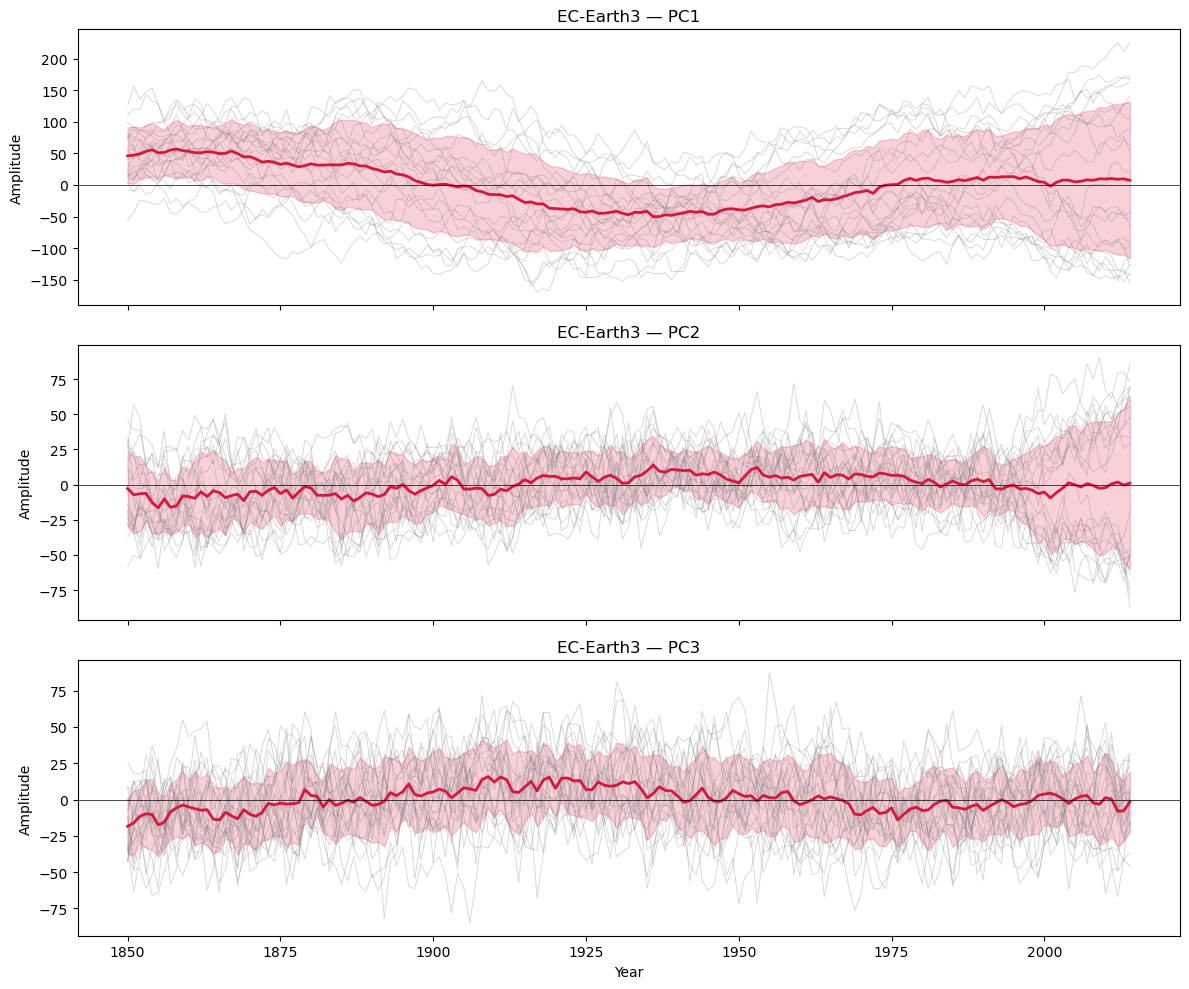

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# LOAD FILE
# -----------------------------
path = "/data/projects/nckf/frekle/EOF_results/EC-Earth3/combined/PC_projected_thetao.nc"
ds = xr.open_dataset(path)

# Rename the ugly variable
PC = ds["__xarray_dataarray_variable__"]
PC.name = "PC"

# PC dims: (member, mode, time)
print("PC shape:", PC.shape)

# Extract time as years
years = ds["time"].dt.year.values


# -----------------------------
# PLOT PC1–PC3 WITH MEAN & STD
# -----------------------------
modes_to_plot = 3
fig, axes = plt.subplots(modes_to_plot, 1, figsize=(12, 10), sharex=True)

for m in range(modes_to_plot):

    pc = PC.isel(mode=m)        # (member, time)
    mean_pc = pc.mean(dim="member")
    std_pc  = pc.std(dim="member")

    ax = axes[m]
    # plot all members faintly
    for i in range(pc.sizes["member"]):
        ax.plot(years, pc.isel(member=i), color="gray", alpha=0.3, lw=0.7)

    # ensemble mean
    ax.plot(years, mean_pc, color="crimson", lw=2, label="Ensemble mean")

    # std shading
    ax.fill_between(years,
                    mean_pc - std_pc,
                    mean_pc + std_pc,
                    color="crimson", alpha=0.2,
                    label="±1 std")

    ax.axhline(0, color="black", lw=0.5)
    ax.set_title(f"EC-Earth3 — PC{m+1}")
    ax.set_ylabel("Amplitude")

axes[-1].set_xlabel("Year")
plt.tight_layout()
plt.show()



### Fix the combined files

In [ ]:
#!/usr/bin/env python3
import xarray as xr
import numpy as np
import os

MODELS = {
    "EC-Earth3":    "/data/projects/nckf/frekle/EOF_results/EC-Earth3/combined/EOF_combined_thetao.nc",
    "IPSL-CM6A-LR": "/data/projects/nckf/frekle/EOF_results/IPSL-CM6A-LR/combined/EOF_combined_thetao.nc",
    "CESM2":        "/data/projects/nckf/frekle/EOF_results/CESM2/combined/EOF_combined_thetao.nc",
}

START_YEAR = 1850
N_YEARS = 165   # 1850–2014


def fix_combined_eof(model, infile):
    print(f"\n=== Fixing {model} ===")

    ds = xr.open_dataset(infile)

    EOF = ds["EOF"]                         # shape (mode, y, x)
    PC_raw = ds["PC"]                       # shape (time_total, mode)
    VF = ds["variance_fraction"]            # shape (mode)

    total_time, n_modes = PC_raw.shape

    # infer number of members
    if total_time % N_YEARS != 0:
        raise ValueError(
            f"{model}: time length {total_time} not divisible by {N_YEARS}. "
            "Check combined EOF source."
        )

    n_members = total_time // N_YEARS
    print(f" → members = {n_members}, years = {N_YEARS}")

    # reshape PC: (time_total, mode) → (member, year, mode)
    pcs = PC_raw.values.reshape(n_members, N_YEARS, n_modes)

    years = np.arange(START_YEAR, START_YEAR + N_YEARS)

    # Create new dataset
    ds_fixed = xr.Dataset(
        {
            "EOF": EOF,
            "PC": (("member", "year", "mode"), pcs),
            "variance_fraction": VF,
        },
        coords={
            "member": np.arange(1, n_members + 1),
            "year": years,
            "mode": np.arange(n_modes),
            "lat": ds["lat"],
            "lon": ds["lon"],
        }
    )

    outfile = infile.replace(".nc", "_FIXED.nc")
    ds_fixed.to_netcdf(outfile)

    print(f" ✔ Saved fixed file: {outfile}")


# Run for all models
for model, infile in MODELS.items():
    fix_combined_eof(model, infile)

print("\n🎉 All combined EOF files have been rebuilt with correct time axis!")



=== Fixing EC-Earth3 ===


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


 → members = 22, years = 165
 ✔ Saved fixed file: /data/projects/nckf/frekle/EOF_results/EC-Earth3/combined/EOF_combined_thetao_FIXED.nc

=== Fixing IPSL-CM6A-LR ===
 → members = 26, years = 165
 ✔ Saved fixed file: /data/projects/nckf/frekle/EOF_results/IPSL-CM6A-LR/combined/EOF_combined_thetao_FIXED.nc

=== Fixing CESM2 ===
 → members = 10, years = 165
 ✔ Saved fixed file: /data/projects/nckf/frekle/EOF_results/CESM2/combined/EOF_combined_thetao_FIXED.nc

🎉 All combined EOF files have been rebuilt with correct time axis!



=== EC-Earth3 ===


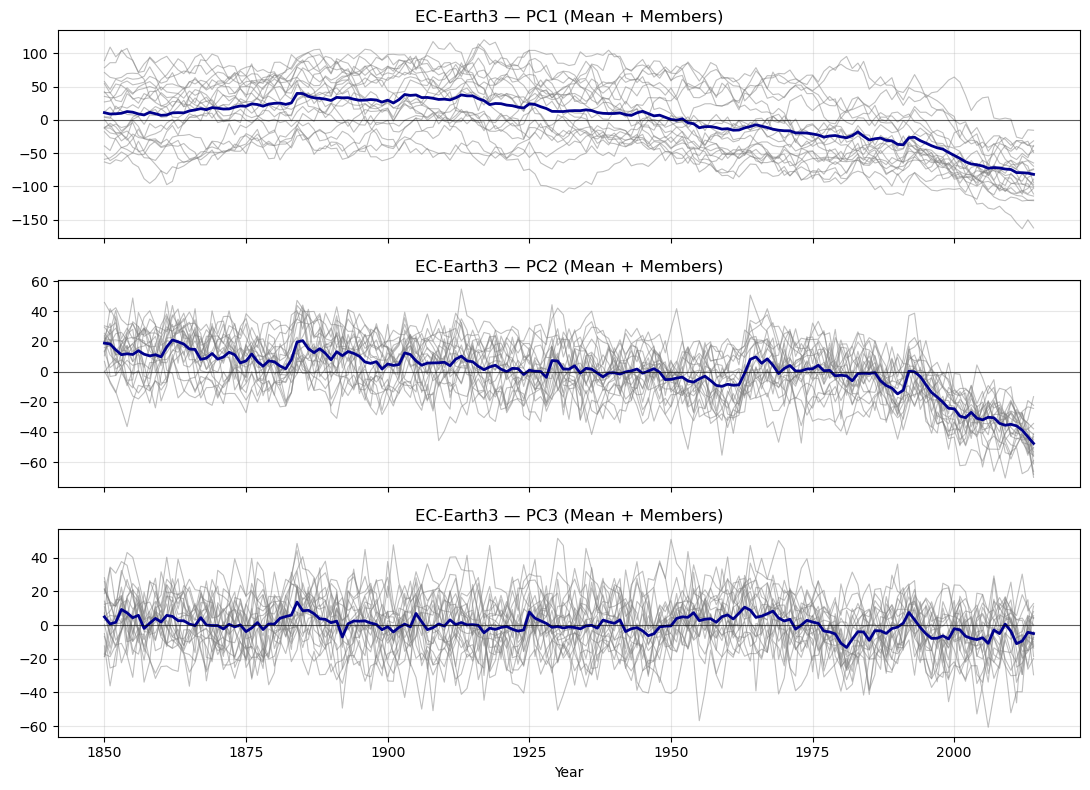


=== IPSL-CM6A-LR ===


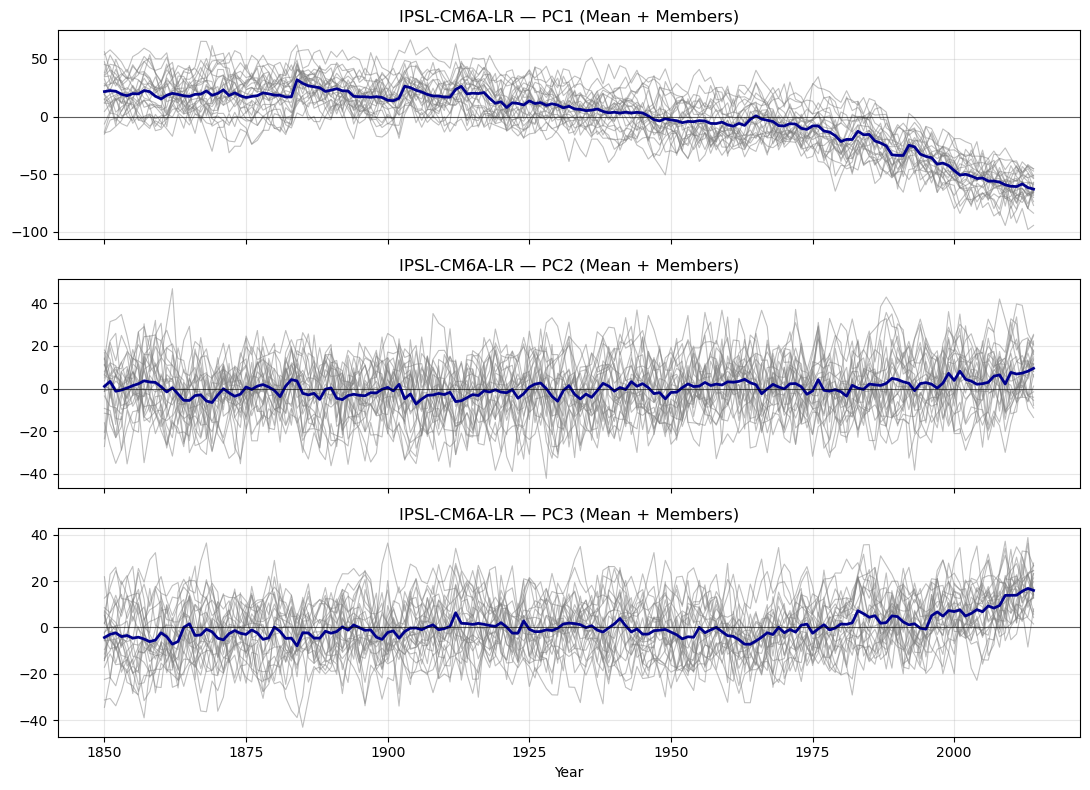


=== CESM2 ===


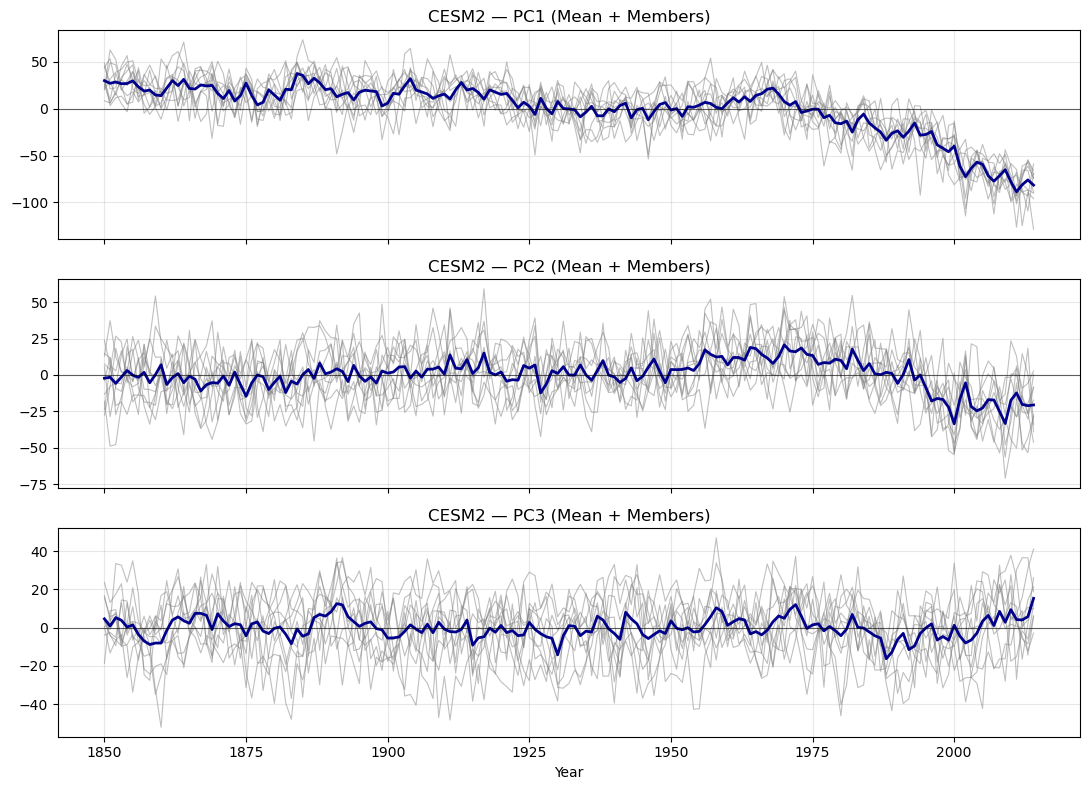

In [ ]:
#!/usr/bin/env python3
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# ===========================================
# Correct paths to PC_projected files
# ===========================================
PC_FILES = {
    "EC-Earth3":     "/data/projects/nckf/frekle/EOF_results/EC-Earth3/combined/EOF_combined_thetao_FIXED.nc",
    "IPSL-CM6A-LR":  "/data/projects/nckf/frekle/EOF_results/IPSL-CM6A-LR/combined/EOF_combined_thetao_FIXED.nc",
    "CESM2":         "/data/projects/nckf/frekle/EOF_results/CESM2/combined/EOF_combined_thetao_FIXED.nc",
}

# ===========================================
# Plot PCs with ensemble mean + individual members
# ===========================================
def plot_pcs_members(model, path):
    print(f"\n=== {model} ===")
    ds = xr.open_dataset(path)

    # PC dimensions: (member, year, mode)
    PC = ds["PC"]
    years = ds["year"].values

    nmodes = min(3, PC.sizes["mode"])

    fig, axes = plt.subplots(nmodes, 1, figsize=(11, 8), sharex=True)

    if nmodes == 1:
        axes = [axes]

    for m in range(nmodes):
        ax = axes[m]

        # --- Mirror individual members ---
        for mem in range(PC.sizes["member"]):
            pc_mem = PC.isel(mode=m, member=mem).values
            ax.plot(years, pc_mem, color="gray", lw=0.8, alpha=0.5)

        # --- Ensemble mean ---
        pc_mean = PC.mean(dim="member").isel(mode=m).values
        ax.plot(years, pc_mean, color="darkblue", lw=2.0, label="Ensemble mean")

        ax.axhline(0, color="black", lw=0.8, alpha=0.6)
        ax.set_title(f"{model} — PC{m+1} (Mean + Members)", fontsize=12)
        ax.grid(alpha=0.3)

        if m == nmodes - 1:
            ax.set_xlabel("Year")

    plt.tight_layout()
    plt.show()


# ===========================================
# MAIN LOOP
# ===========================================
for model, path in PC_FILES.items():
    plot_pcs_members(model, path)



=== EC-Earth3 ===
→ Spatial EOFs


/tmp/ipykernel_282913/444169356.py:36: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(np.abs(field))


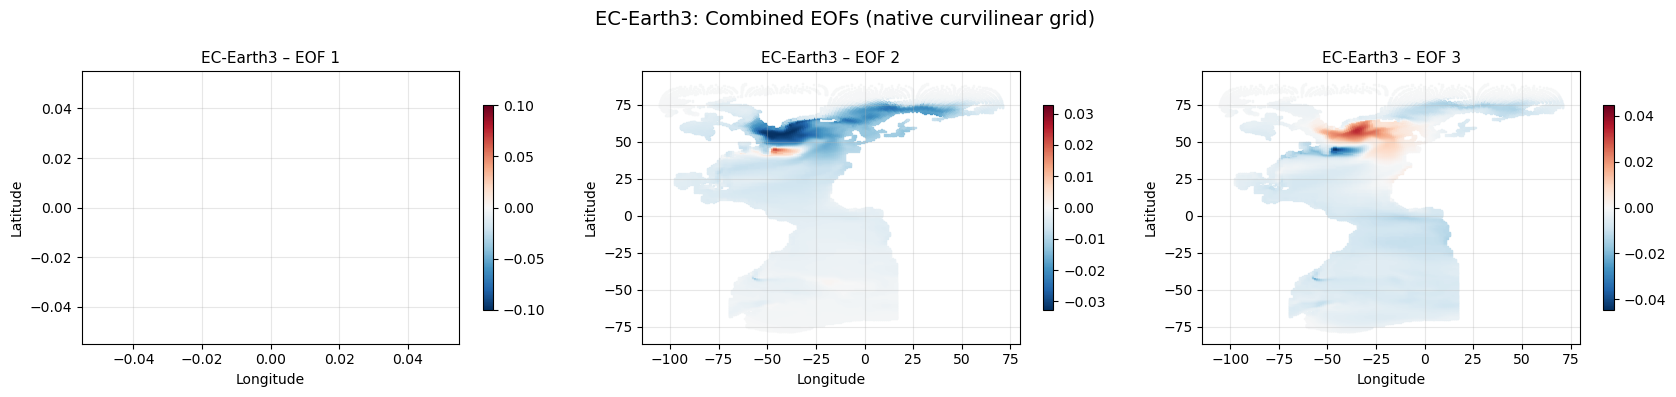

→ PC time series


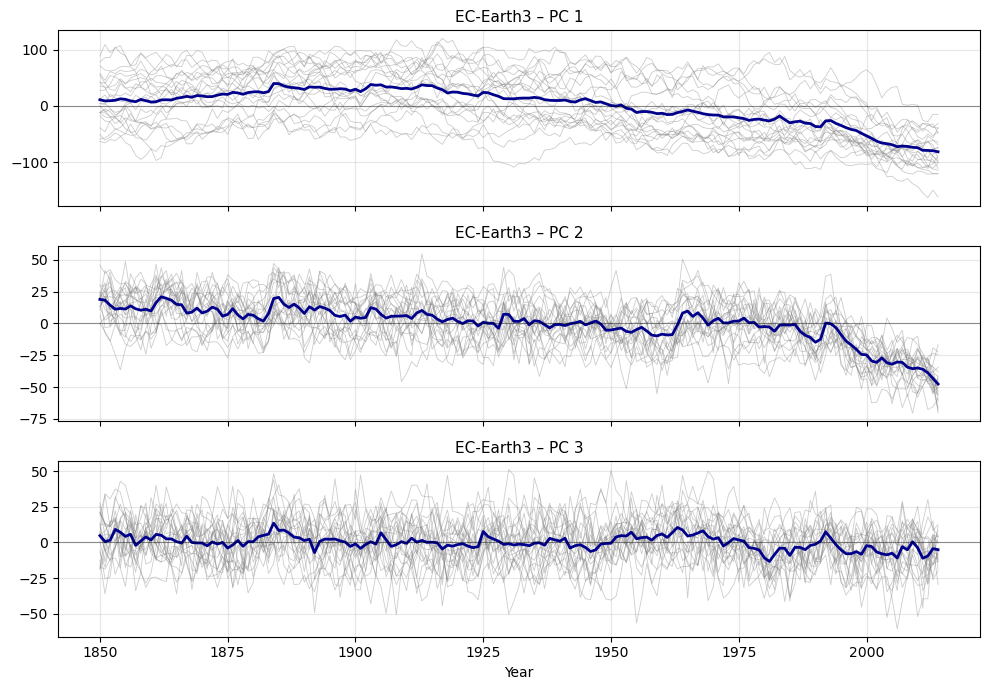


=== IPSL-CM6A-LR ===
→ Spatial EOFs


/tmp/ipykernel_282913/444169356.py:36: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(np.abs(field))


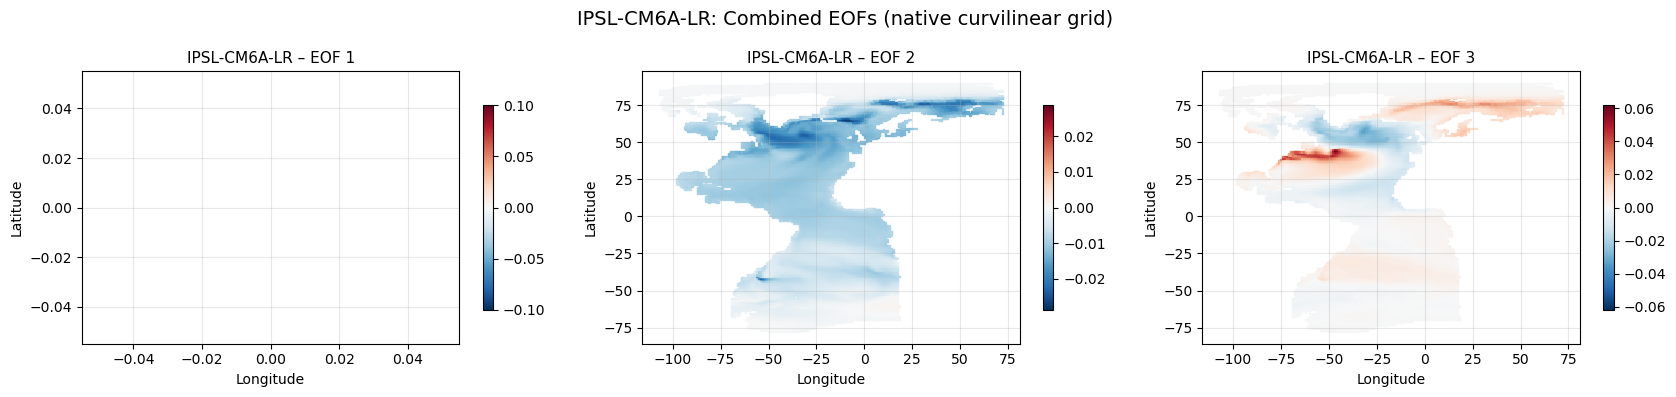

→ PC time series


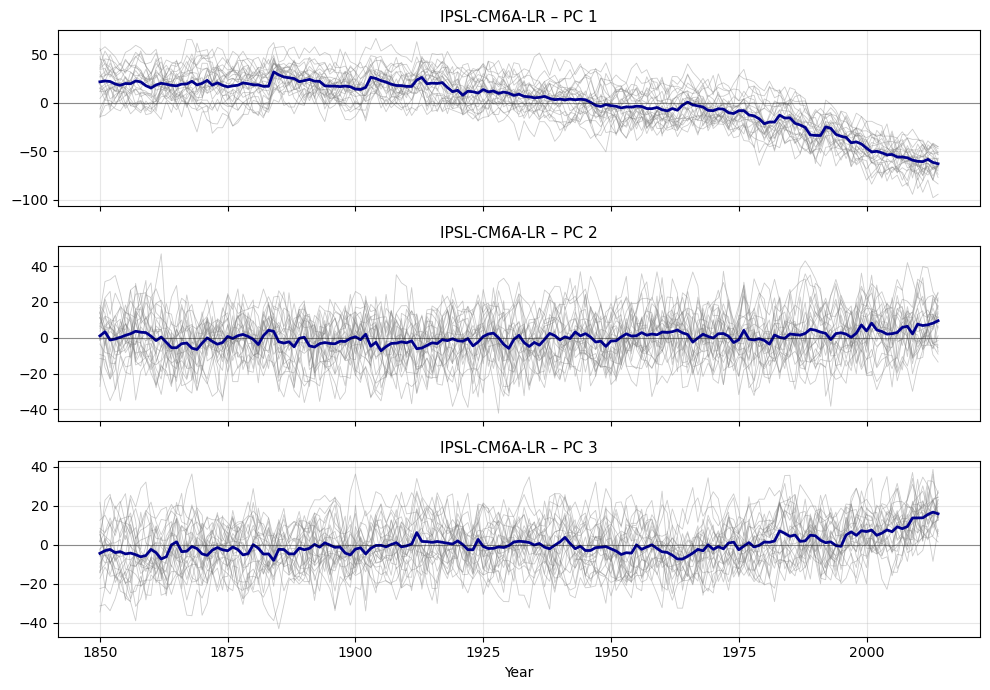


=== CESM2 ===
→ Spatial EOFs


/tmp/ipykernel_282913/444169356.py:36: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(np.abs(field))


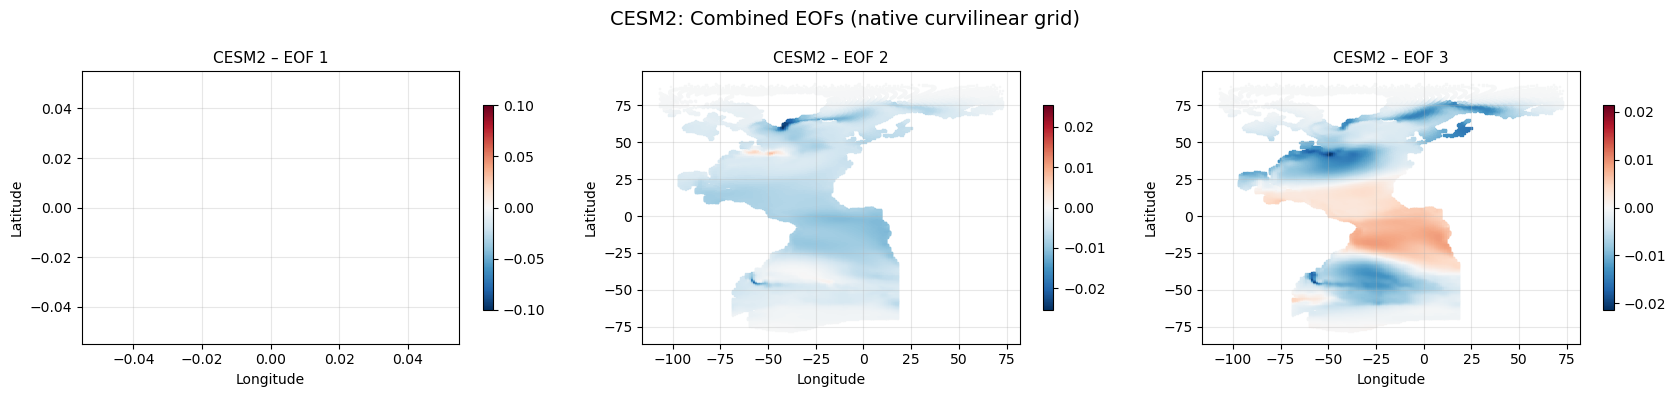

→ PC time series


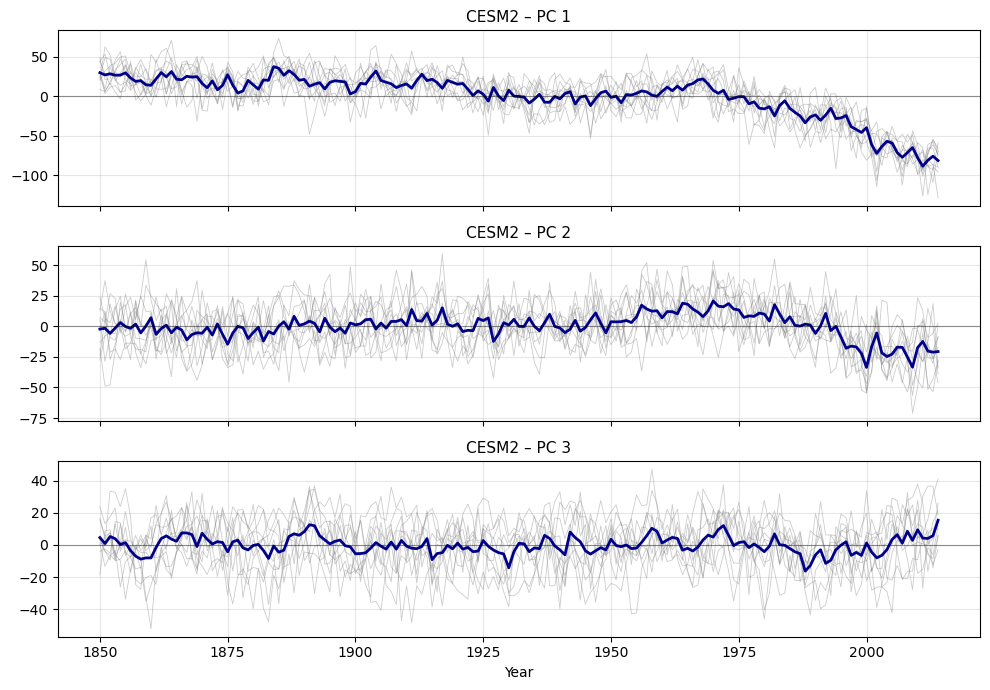


🎉 Finished plotting spatial + temporal EOFs for all models!


In [ ]:
#!/usr/bin/env python3
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ===========================================
# Paths – combined EOF + PC files
# ===========================================
COMBINED = {
    "EC-Earth3":     "/data/projects/nckf/frekle/EOF_results/EC-Earth3/combined/EOF_combined_thetao_FIXED.nc",
    "IPSL-CM6A-LR":  "/data/projects/nckf/frekle/EOF_results/IPSL-CM6A-LR/combined/EOF_combined_thetao_FIXED.nc",
    "CESM2":         "/data/projects/nckf/frekle/EOF_results/CESM2/combined/EOF_combined_thetao_FIXED.nc",
}

# ===========================================
# Spatial EOFs using SCATTER on curvilinear grid
# ===========================================
def plot_eofs_native(ds, model):
    EOF = ds["EOF"]             # (mode, y, x)
    lat = ds["lat"]             # (y, x)
    lon = ds["lon"]             # (y, x)

    # Wrap longitudes into [-180, 180]
    lon2 = ((lon + 180) % 360) - 180

    nmodes = min(3, EOF.sizes["mode"])
    fig, axes = plt.subplots(1, nmodes, figsize=(17, 4))

    if nmodes == 1:
        axes = [axes]

    for m in range(nmodes):
        ax = axes[m]

        field = EOF.isel(mode=m).values
        vmax = np.nanmax(np.abs(field))

        sc = ax.scatter(
            lon2.values.flatten(),
            lat.values.flatten(),
            c=field.flatten(),
            s=1.0,
            cmap="RdBu_r",
            vmin=-vmax,
            vmax=vmax,
            marker="s"
        )

        ax.set_title(f"{model} – EOF {m+1}", fontsize=11)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(alpha=0.3)

        plt.colorbar(sc, ax=ax, shrink=0.75)

    plt.suptitle(f"{model}: Combined EOFs (native curvilinear grid)", fontsize=14)
    plt.tight_layout()
    plt.show()


# ===========================================
# Plot PCs (members + ensemble mean)
# ===========================================
def plot_pcs(ds, model):
    PC = ds["PC"]               # (member, year, mode)
    years = ds["year"].values   # correct 1850–2014

    nmodes = min(3, PC.sizes["mode"])
    fig, axes = plt.subplots(nmodes, 1, figsize=(10, 7), sharex=True)

    if nmodes == 1:
        axes = [axes]

    for m in range(nmodes):
        ax = axes[m]

        # Individual members (gray)
        for mem in range(PC.sizes["member"]):
            ax.plot(
                years,
                PC.isel(member=mem, mode=m).values,
                color="gray",
                alpha=0.4,
                lw=0.6
            )

        # Ensemble mean (dark blue)
        mean_pc = PC.mean(dim="member").isel(mode=m).values
        ax.plot(
            years,
            mean_pc,
            color="darkblue",
            lw=2.0,
            label="Ensemble mean"
        )

        ax.axhline(0, color="k", lw=0.8, alpha=0.4)
        ax.set_title(f"{model} – PC {m+1}", fontsize=11)
        ax.grid(alpha=0.3)

        if m == nmodes - 1:
            ax.set_xlabel("Year")

    plt.tight_layout()
    plt.show()


# ===========================================
# MAIN LOOP
# ===========================================
for model, path in COMBINED.items():
    print(f"\n=== {model} ===")
    ds = xr.open_dataset(path)

    print("→ Spatial EOFs")
    plot_eofs_native(ds, model)

    print("→ PC time series")
    plot_pcs(ds, model)

print("\n🎉 Finished plotting spatial + temporal EOFs for all models!")


In [ ]:
import xarray as xr
import numpy as np

path = "/data/projects/nckf/frekle/EOF_results/EC-Earth3/combined/EOF_combined_thetao_FIXED.nc"
ds = xr.open_dataset(path)

EOF = ds["EOF"]

print("EOF dims:", EOF.dims)
print("EOF shape:", EOF.shape)

# Check NaNs in EOF1
e1 = EOF.isel(mode=0)
print("EOF1 NaN fraction:", np.isnan(e1.values).mean())

# Show min/max (ignoring NaNs)
print("EOF1 min/max:", np.nanmin(e1.values), np.nanmax(e1.values))


EOF dims: ('mode', 'y', 'x')
EOF shape: (50, 292, 362)
EOF1 NaN fraction: 1.0
EOF1 min/max: nan nan


/tmp/ipykernel_282913/1075588888.py:17: RuntimeWarning: All-NaN slice encountered
  print("EOF1 min/max:", np.nanmin(e1.values), np.nanmax(e1.values))



📘 Plotting EOF + PC for EC-Earth3
💾 Saved: /data/projects/nckf/frekle/EOF_plots/EC-Earth3_EOF_PC_first3.png


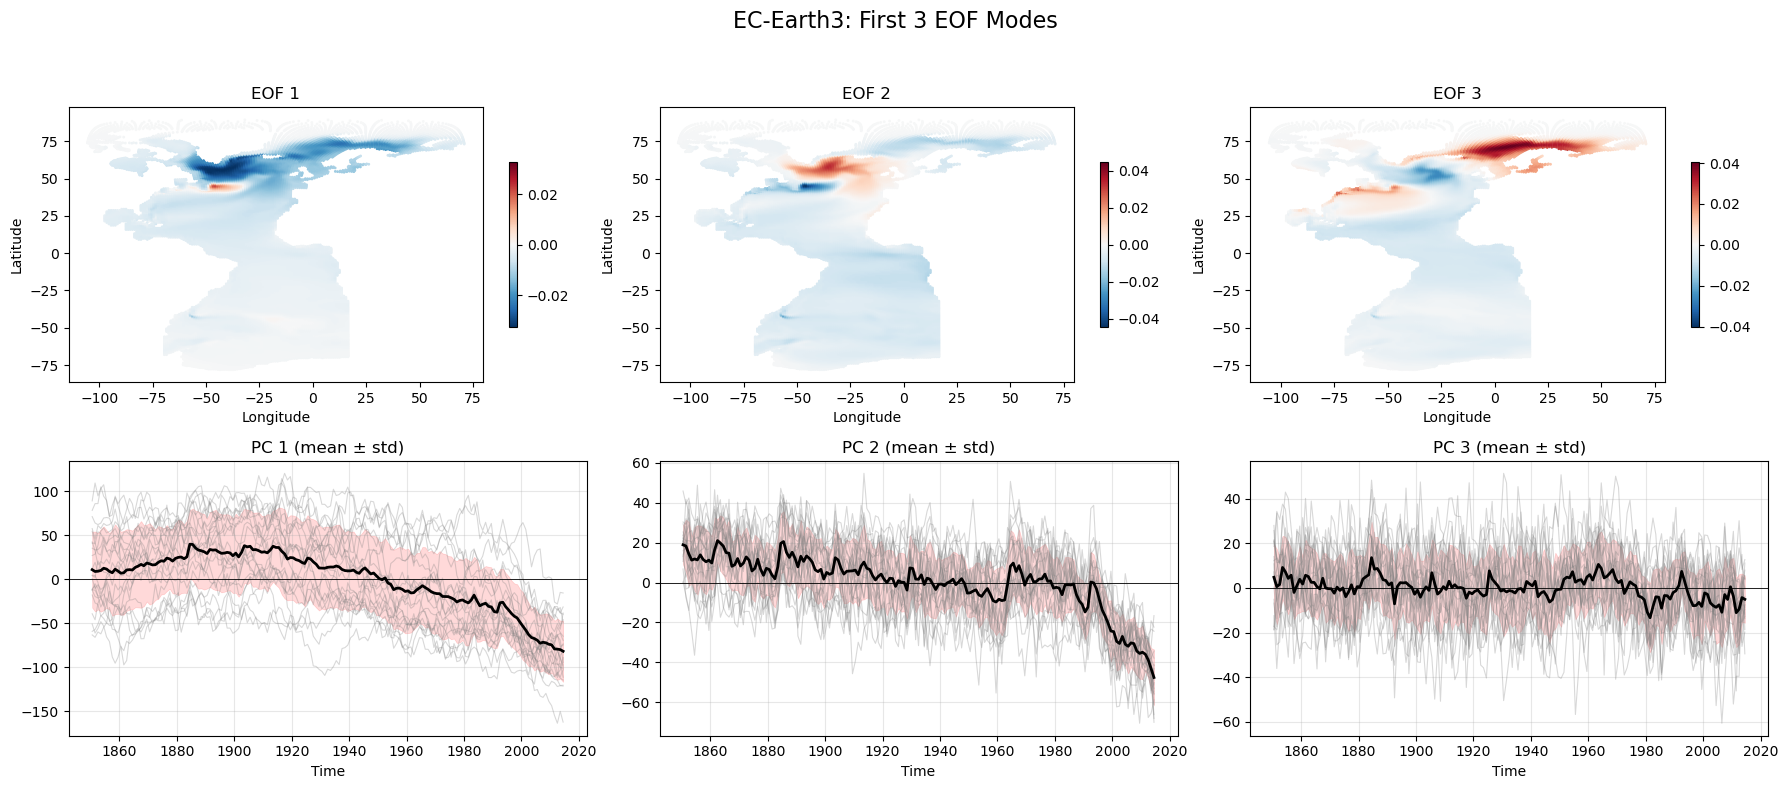


📘 Plotting EOF + PC for CESM2
   → Converting cftime → datetime64 for CESM2


/tmp/ipykernel_287731/3555835496.py:72: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  time_np = ds.indexes["time"].to_datetimeindex()


💾 Saved: /data/projects/nckf/frekle/EOF_plots/CESM2_EOF_PC_first3.png


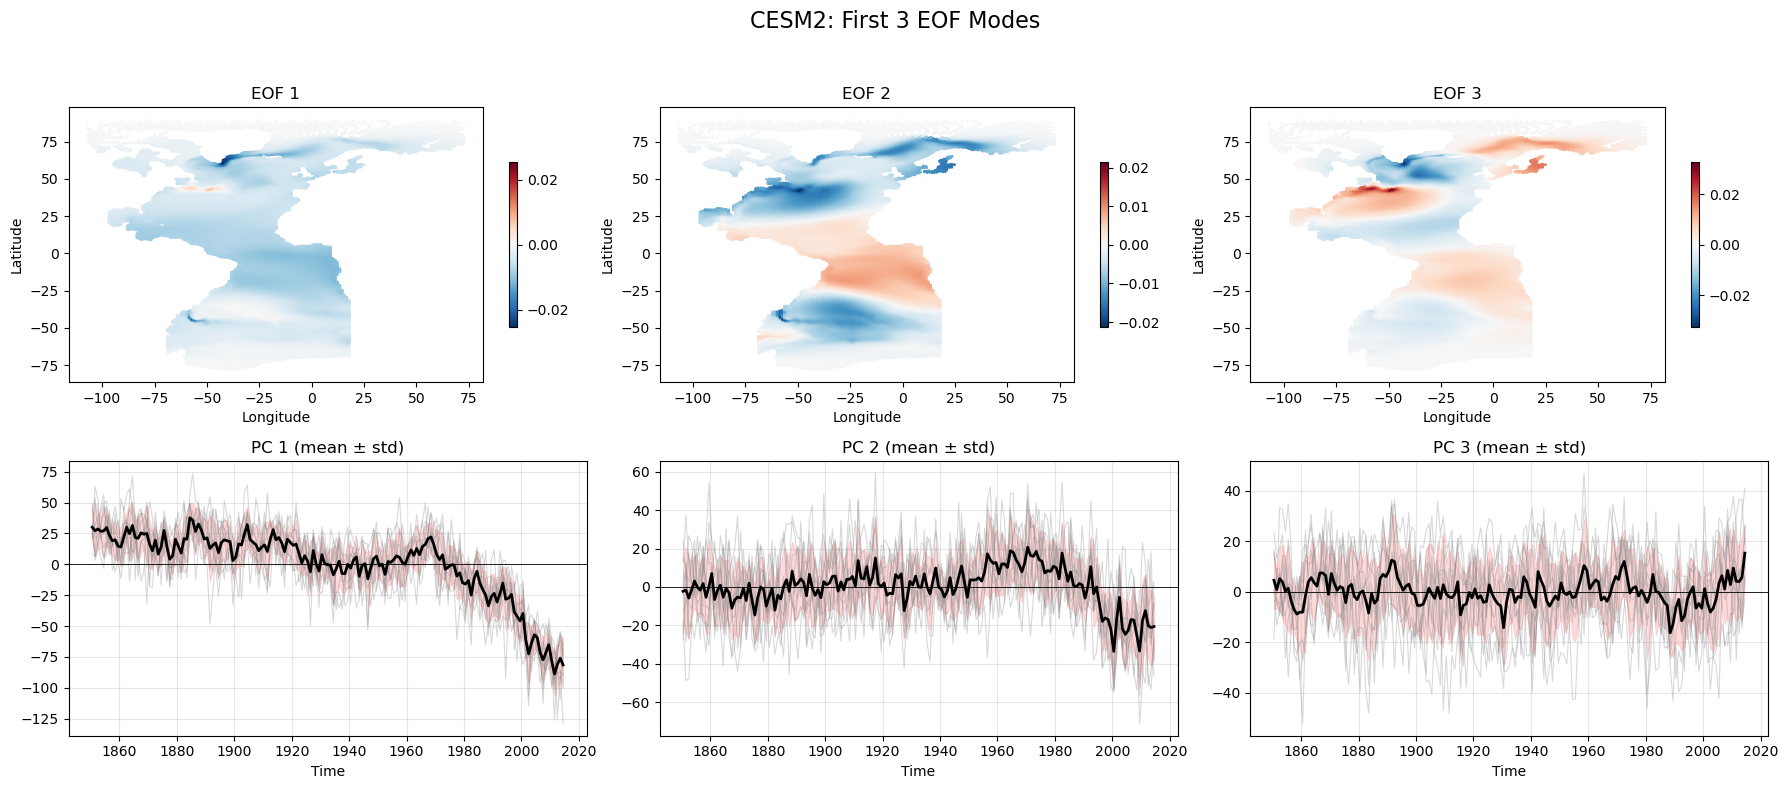


📘 Plotting EOF + PC for IPSL-CM6A-LR
💾 Saved: /data/projects/nckf/frekle/EOF_plots/IPSL-CM6A-LR_EOF_PC_first3.png


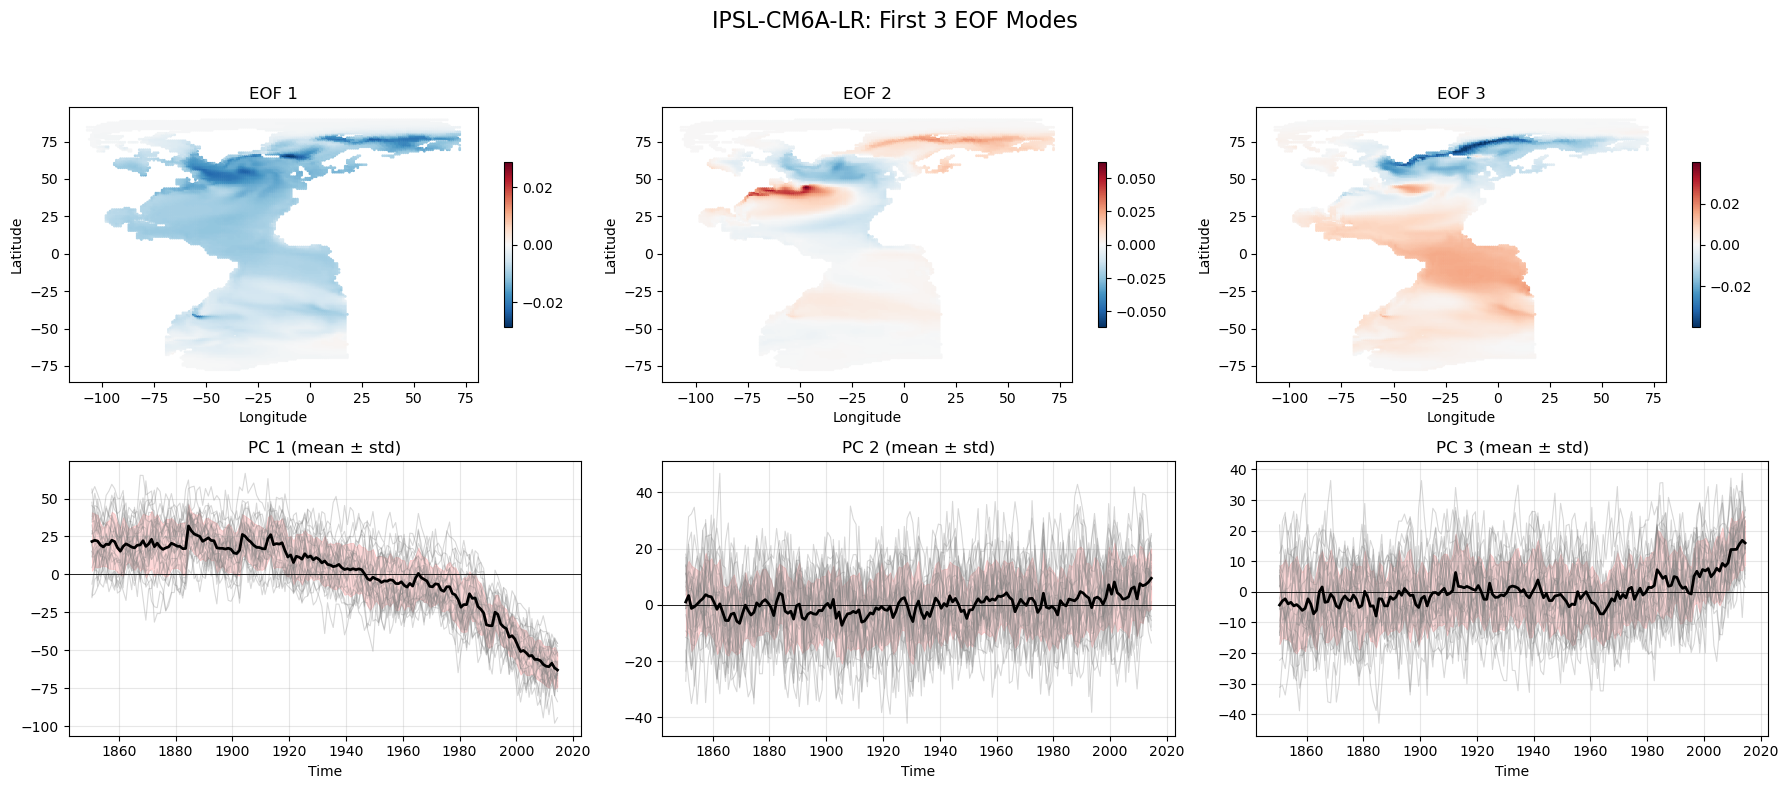


🎉 All model plots complete!



In [3]:
#!/usr/bin/env python3
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================
# SETTINGS
# ============================================
MODELS = ["EC-Earth3", "CESM2", "IPSL-CM6A-LR"]
VAR    = "thetao"
EOF_DIR = "/data/projects/nckf/frekle/EOF_results"
OUT_DIR = "/data/projects/nckf/frekle/EOF_plots"
os.makedirs(OUT_DIR, exist_ok=True)

NMODES = 3   # plot EOF/PC modes 1–3


# ============================================
# Helper: symmetric color range
# ============================================
def symmetric_clim(field):
    vmax = np.nanmax(np.abs(field))
    return -vmax, vmax


# ============================================
# Helper: Native-grid scatter-method EOF plotting
# (works for 1D, 2D, and curvilinear grids)
# ============================================
def plot_eof_native(ax, lat, lon, eof_field, mode):
    lon2 = ((lon + 180) % 360) - 180   # wrap longitude to [-180,180]

    vmin, vmax = symmetric_clim(eof_field)

    sc = ax.scatter(
        lon2.values, lat.values,
        c=eof_field.values,
        s=1.0,
        cmap="RdBu_r",
        vmin=vmin, vmax=vmax,
    )

    ax.set_title(f"EOF {mode+1}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.colorbar(sc, ax=ax, shrink=0.6)


# ============================================
# MAIN LOOP OVER MODELS
# ============================================
for model in MODELS:

    print(f"\n📘 Plotting EOF + PC for {model}")

    # --- load file ---
    f = f"{EOF_DIR}/{model}/combined/EOF_combined_{VAR}_with_time.nc"
    ds = xr.open_dataset(f)

    EOF = ds["EOF"]         # (mode, y, x)
    PC  = ds["PC"]          # (member, time, mode)
    lat = ds["lat"]         # (y, x)
    lon = ds["lon"]         # (y, x)

    # ============================================
    # FIX TIME AXIS (CESM uses cftime)
    # ============================================
    if not np.issubdtype(ds["time"].dtype, np.datetime64):
        print(f"   → Converting cftime → datetime64 for {model}")
        try:
            time_np = ds.indexes["time"].to_datetimeindex()
        except Exception:
            # fallback: convert to strings, then to datetime
            time_np = ds["time"].dt.strftime("%Y-%m-%d").astype("datetime64[ns]")
    else:
        time_np = ds["time"].values

    # ============================================
    # CREATE FIGURE
    # ============================================
    fig, axes = plt.subplots(2, NMODES, figsize=(18, 8))
    fig.suptitle(f"{model}: First 3 EOF Modes", fontsize=16)

    # ============================
    # 1. EOF Spatial Maps
    # ============================
    for m in range(NMODES):
        field = EOF.isel(mode=m)
        plot_eof_native(axes[0, m], lat, lon, field, m)

    # ============================
    # 2. PC Timeseries
    # ============================
    for m in range(NMODES):
        ax = axes[1, m]

        pcs_all  = PC.isel(mode=m)        # (member, time)
        pcs_mean = pcs_all.mean("member") # (time)
        pcs_std  = pcs_all.std("member")  # (time)

        # ---- plot each member ----
        for mem in range(pcs_all.sizes["member"]):
            ax.plot(
                time_np,
                pcs_all.isel(member=mem),
                color="gray",
                alpha=0.3,
                lw=0.8
            )

        # ---- mean line ----
        ax.plot(
            time_np, pcs_mean,
            color="black",
            lw=2,
            label="Mean"
        )

        # ---- ± std shading ----
                # thin red standard deviation band
        ax.fill_between(
            time_np,
            pcs_mean - pcs_std,
            pcs_mean + pcs_std,
            color="red",
            alpha=0.15,         # thin transparent band
            edgecolor="red",
            linewidth=0.5,
            label="±1 std"
        )


        ax.axhline(0, color="black", lw=0.6)
        ax.grid(alpha=0.3)
        ax.set_title(f"PC {m+1} (mean ± std)")
        ax.set_xlabel("Time")

    fig.tight_layout(rect=[0, 0, 1, 0.95])

    outfile = f"{OUT_DIR}/{model}_EOF_PC_first3.png"
    fig.savefig(outfile, dpi=150)
    print(f"💾 Saved: {outfile}")

    plt.show()

print("\n🎉 All model plots complete!\n")


## Diagnostic matrixes

In [5]:
#!/usr/bin/env python3
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================
MODELS = ["EC-Earth3", "CESM2", "IPSL-CM6A-LR"]
VAR = "thetao"
EOF_DIR = "/data/projects/nckf/frekle/EOF_results"
OUT_DIR = "/data/users/frekle/EOF/EOF_diagnostics"
os.makedirs(OUT_DIR, exist_ok=True)

# Number of leading modes to analyze
NMODES = 10          # analyze PCs 1–10
PLOT_MODES = 3       # plot PC1–PC3 in some diagnostics


# ============================================================
# Helper: Convert CESM cftime → numpy datetime
# ============================================================
def convert_time(ds):
    """Safely converts CFTimeIndex to numpy.datetime64."""
    if not np.issubdtype(ds["time"].dtype, np.datetime64):
        try:
            return ds.indexes["time"].to_datetimeindex()
        except Exception:
            # fallback: convert to string then to datetime
            return ds["time"].dt.strftime("%Y-%m-%d").astype("datetime64[ns]")
    return ds["time"].values


# ============================================================
# Helper: correlation matrix
# ============================================================
def corr_matrix(mat):
    """
    mat: (samples, variables)
    returns correlation matrix
    """
    return np.corrcoef(mat, rowvar=False)


# ============================================================
# MAIN ANALYSIS LOOP
# ============================================================
for model in MODELS:

    print(f"\n📘 Running diagnostics for {model}")

    # ------------------------------
    # Load combined EOF file
    # ------------------------------
    f = f"{EOF_DIR}/{model}/combined/EOF_combined_{VAR}_with_time.nc"
    ds = xr.open_dataset(f)

    PC  = ds["PC"]          # (member, time, mode)
    time_np = convert_time(ds)

    nmembers = PC.sizes["member"]
    nt = PC.sizes["time"]
    nmodes_total = PC.sizes["mode"]

    # Restrict to first N modes for analysis
    PC_sel = PC.isel(mode=slice(0, NMODES))


    # ============================================================
    # A) MODE × MODE PC CORRELATION MATRIX
    # ============================================================
    print("   → Computing Mode × Mode correlation matrix")

    # Build matrix (samples = member*time)
    mat = PC_sel.values.reshape(nmembers * nt, NMODES)

    C = corr_matrix(mat)  # (NMODES × NMODES)

    plt.figure(figsize=(7, 6))
    plt.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(label="Correlation")
    plt.title(f"{model} – Mode × Mode PC Correlation")
    plt.xlabel("Mode")
    plt.ylabel("Mode")
    plt.xticks(np.arange(NMODES), np.arange(1, NMODES + 1))
    plt.yticks(np.arange(NMODES), np.arange(1, NMODES + 1))
    plt.tight_layout()

    out = f"{OUT_DIR}/{model}_PC_mode_correlation.png"
    plt.savefig(out, dpi=150)
    print(f"      Saved: {out}")
    plt.close()


    # ============================================================
    # B) MEMBER × MEMBER CORRELATION (PC1–PC3)
    # ============================================================
    for m in range(PLOT_MODES):

        print(f"   → Computing Member × Member correlation matrix for PC{m+1}")

        # Use isel() instead of sel() — FIXED
        pc_m = PC.isel(mode=m)   # (member, time)

        # matrix shape for corrcoef: (time, members)
        mat_m = pc_m.values.T

        C_mem = corr_matrix(mat_m)  # (member × member)

        plt.figure(figsize=(7, 6))
        plt.imshow(C_mem, cmap="RdBu_r", vmin=-1, vmax=1)
        plt.colorbar(label="Correlation")
        plt.title(f"{model} – PC{m+1}: Member × Member Correlation")
        plt.xlabel("Member")
        plt.ylabel("Member")

        ticks = np.arange(nmembers)
        plt.xticks(ticks, ds["member"].values, rotation=90)
        plt.yticks(ticks, ds["member"].values)
        plt.tight_layout()

        out = f"{OUT_DIR}/{model}_PC_member_correlation_PC{m+1}.png"
        plt.savefig(out, dpi=150)
        print(f"      Saved: {out}")
        plt.close()


    # ============================================================
    # C) TIME × MODE PC-AMPlITUDE HEATMAP
    # ============================================================
    print("   → Creating Time × Mode PC amplitude heatmap (|PC|)")

    PC_mean = PC.mean("member")  # (time, mode)
    PC_abs = np.abs(PC_mean.isel(mode=slice(0, PLOT_MODES)))

    plt.figure(figsize=(8, 5))
    plt.imshow(
        PC_abs.T,
        aspect='auto',
        cmap="magma",
        interpolation="nearest",
        extent=[0, nt, 1, PLOT_MODES]
    )

    plt.colorbar(label="|PC amplitude|")
    plt.title(f"{model} – Time × Mode Mean PC Amplitude")
    plt.xlabel("Time index")
    plt.ylabel("Mode")
    plt.yticks(np.arange(1, PLOT_MODES+1))
    plt.tight_layout()

    out = f"{OUT_DIR}/{model}_PC_time_mode_heatmap.png"
    plt.savefig(out, dpi=150)
    print(f"      Saved: {out}")
    plt.close()


print("\n🎉 All diagnostics complete successfully!\n")



📘 Running diagnostics for EC-Earth3
   → Computing Mode × Mode correlation matrix
      Saved: /data/users/frekle/EOF/EOF_diagnostics/EC-Earth3_PC_mode_correlation.png
   → Computing Member × Member correlation matrix for PC1
      Saved: /data/users/frekle/EOF/EOF_diagnostics/EC-Earth3_PC_member_correlation_PC1.png
   → Computing Member × Member correlation matrix for PC2
      Saved: /data/users/frekle/EOF/EOF_diagnostics/EC-Earth3_PC_member_correlation_PC2.png
   → Computing Member × Member correlation matrix for PC3
      Saved: /data/users/frekle/EOF/EOF_diagnostics/EC-Earth3_PC_member_correlation_PC3.png
   → Creating Time × Mode PC amplitude heatmap (|PC|)
      Saved: /data/users/frekle/EOF/EOF_diagnostics/EC-Earth3_PC_time_mode_heatmap.png

📘 Running diagnostics for CESM2
   → Computing Mode × Mode correlation matrix


/tmp/ipykernel_287731/2932972882.py:28: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  return ds.indexes["time"].to_datetimeindex()


      Saved: /data/users/frekle/EOF/EOF_diagnostics/CESM2_PC_mode_correlation.png
   → Computing Member × Member correlation matrix for PC1
      Saved: /data/users/frekle/EOF/EOF_diagnostics/CESM2_PC_member_correlation_PC1.png
   → Computing Member × Member correlation matrix for PC2
      Saved: /data/users/frekle/EOF/EOF_diagnostics/CESM2_PC_member_correlation_PC2.png
   → Computing Member × Member correlation matrix for PC3
      Saved: /data/users/frekle/EOF/EOF_diagnostics/CESM2_PC_member_correlation_PC3.png
   → Creating Time × Mode PC amplitude heatmap (|PC|)
      Saved: /data/users/frekle/EOF/EOF_diagnostics/CESM2_PC_time_mode_heatmap.png

📘 Running diagnostics for IPSL-CM6A-LR
   → Computing Mode × Mode correlation matrix
      Saved: /data/users/frekle/EOF/EOF_diagnostics/IPSL-CM6A-LR_PC_mode_correlation.png
   → Computing Member × Member correlation matrix for PC1
      Saved: /data/users/frekle/EOF/EOF_diagnostics/IPSL-CM6A-LR_PC_member_correlation_PC1.png
   → Computing 


📘 Running diagnostics for EC-Earth3


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


   → Computing correct Mode × Mode correlation matrix


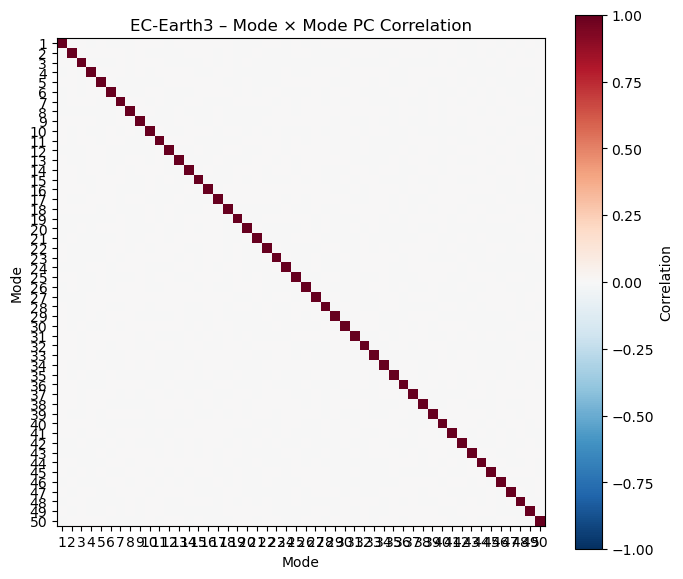

      Saved: /data/users/frekle/EOF/EOF_diagnostics/EC-Earth3_PC_mode_correlation.png
   → Computing Member × Member correlation matrix for PC1


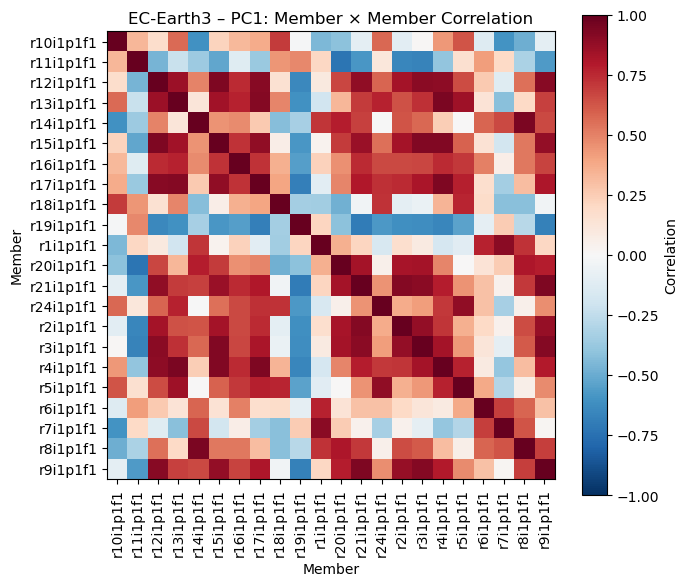

      Saved: /data/users/frekle/EOF/EOF_diagnostics/EC-Earth3_PC_member_correlation_PC1.png
   → Computing Member × Member correlation matrix for PC2


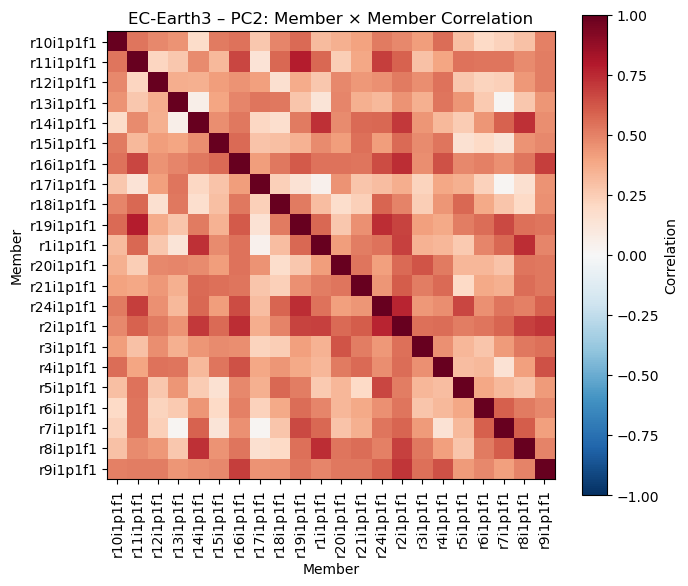

      Saved: /data/users/frekle/EOF/EOF_diagnostics/EC-Earth3_PC_member_correlation_PC2.png
   → Computing Member × Member correlation matrix for PC3


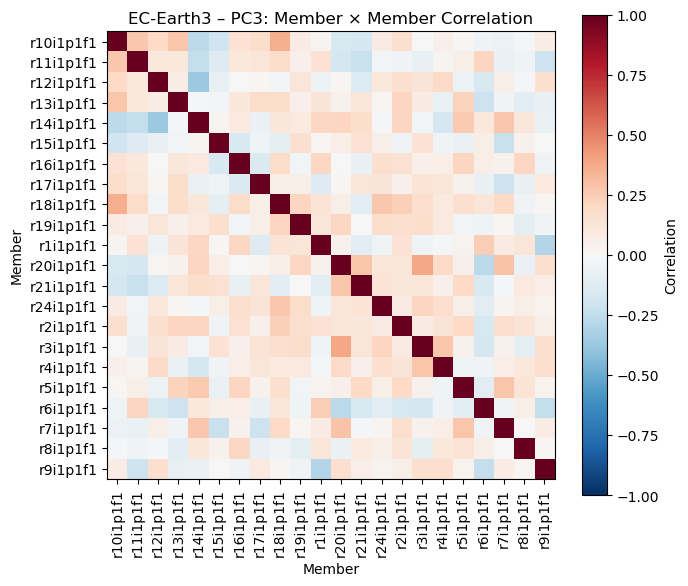

      Saved: /data/users/frekle/EOF/EOF_diagnostics/EC-Earth3_PC_member_correlation_PC3.png
   → Creating Time × Mode PC amplitude heatmap (|PC|)


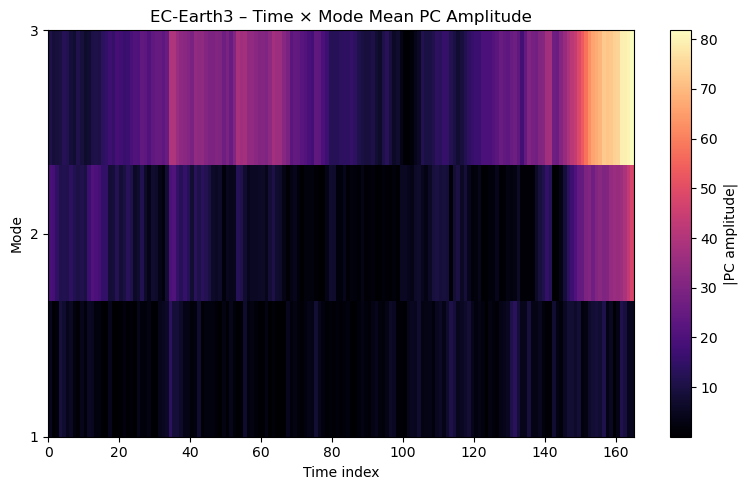

      Saved: /data/users/frekle/EOF/EOF_diagnostics/EC-Earth3_PC_time_mode_heatmap.png

📘 Running diagnostics for CESM2
   → Computing correct Mode × Mode correlation matrix


/tmp/ipykernel_419283/3546072122.py:27: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  return ds.indexes["time"].to_datetimeindex()


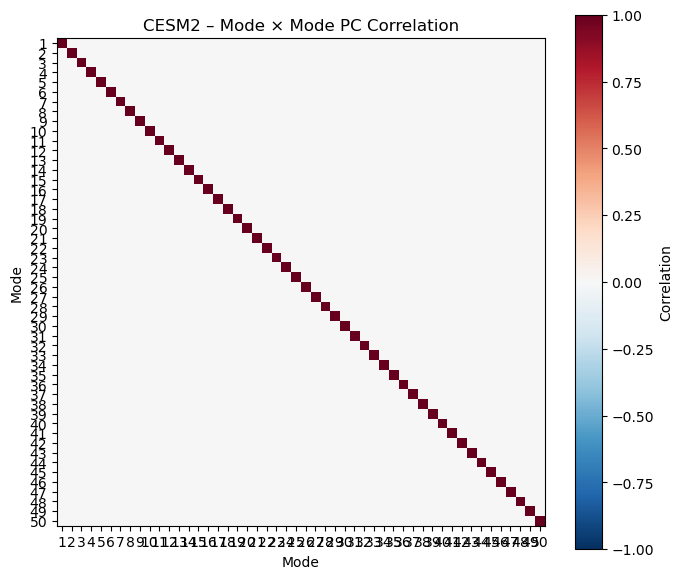

      Saved: /data/users/frekle/EOF/EOF_diagnostics/CESM2_PC_mode_correlation.png
   → Computing Member × Member correlation matrix for PC1


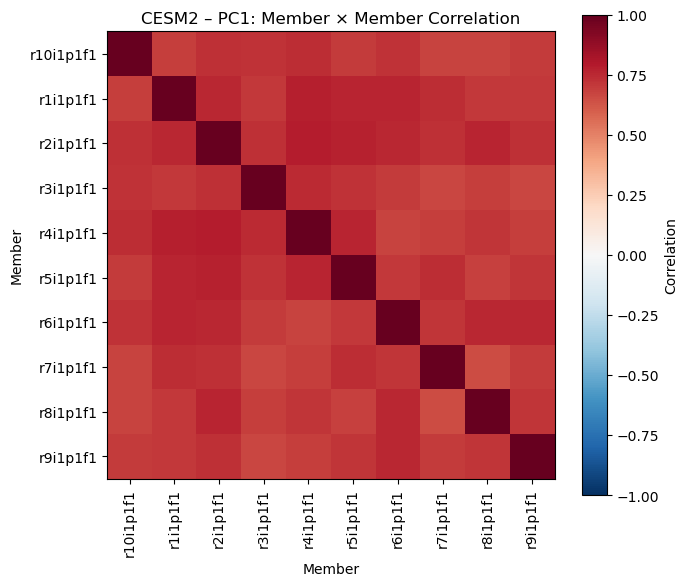

      Saved: /data/users/frekle/EOF/EOF_diagnostics/CESM2_PC_member_correlation_PC1.png
   → Computing Member × Member correlation matrix for PC2


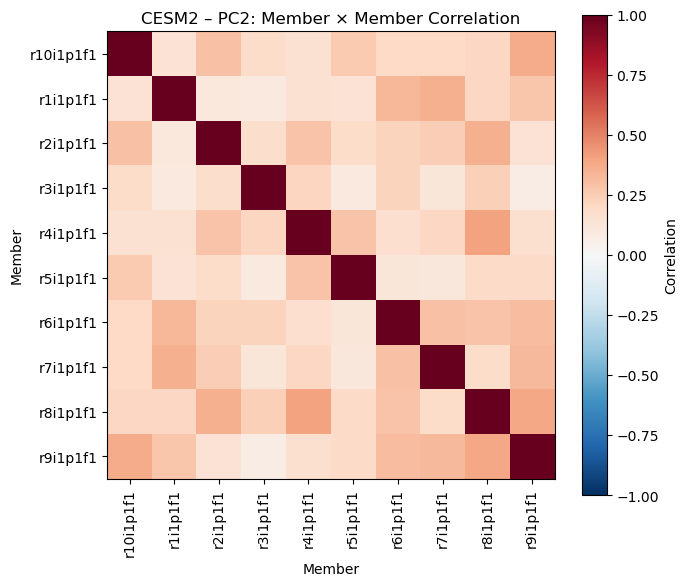

      Saved: /data/users/frekle/EOF/EOF_diagnostics/CESM2_PC_member_correlation_PC2.png
   → Computing Member × Member correlation matrix for PC3


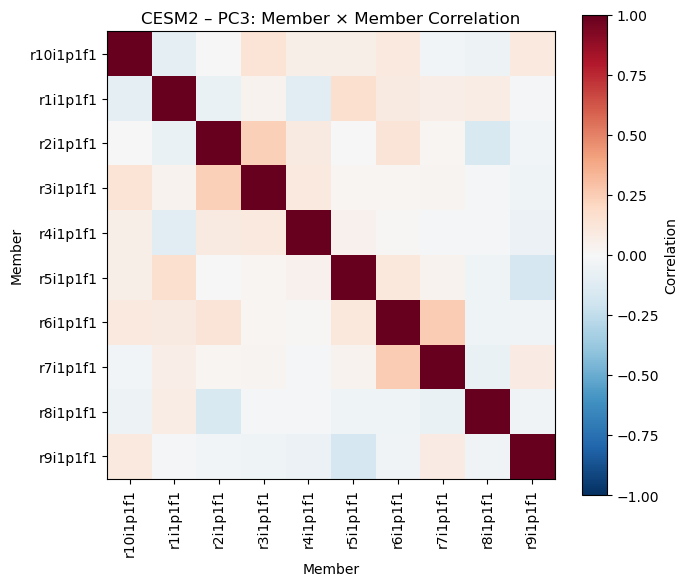

      Saved: /data/users/frekle/EOF/EOF_diagnostics/CESM2_PC_member_correlation_PC3.png
   → Creating Time × Mode PC amplitude heatmap (|PC|)


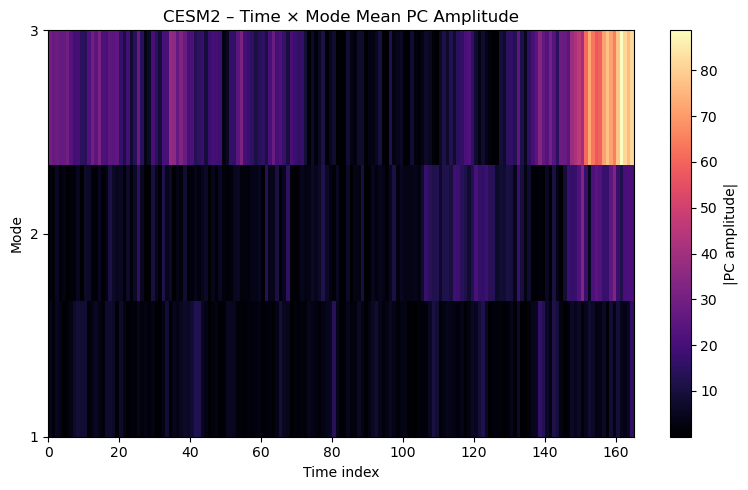

      Saved: /data/users/frekle/EOF/EOF_diagnostics/CESM2_PC_time_mode_heatmap.png

📘 Running diagnostics for IPSL-CM6A-LR
   → Computing correct Mode × Mode correlation matrix


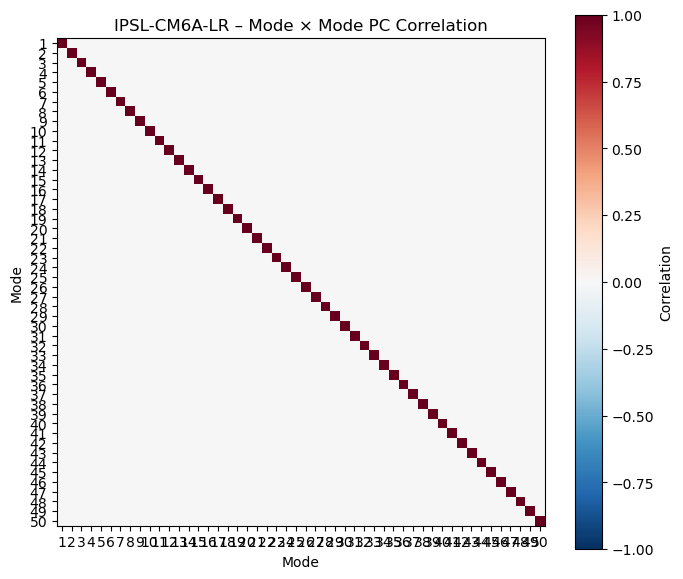

      Saved: /data/users/frekle/EOF/EOF_diagnostics/IPSL-CM6A-LR_PC_mode_correlation.png
   → Computing Member × Member correlation matrix for PC1


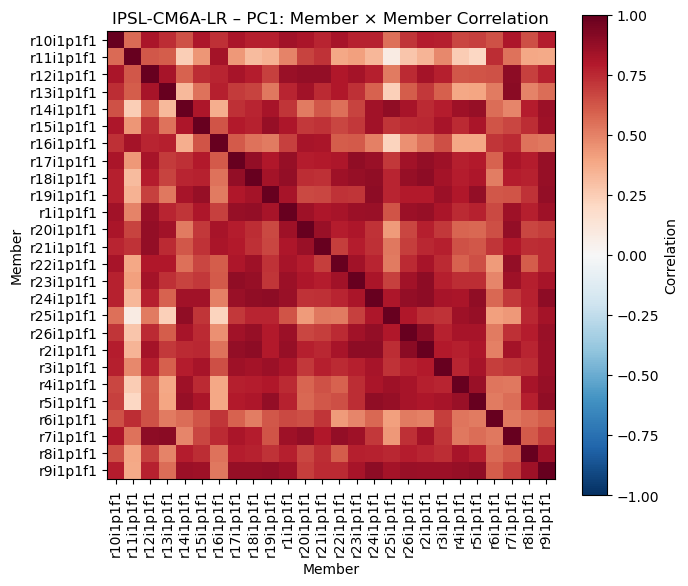

      Saved: /data/users/frekle/EOF/EOF_diagnostics/IPSL-CM6A-LR_PC_member_correlation_PC1.png
   → Computing Member × Member correlation matrix for PC2


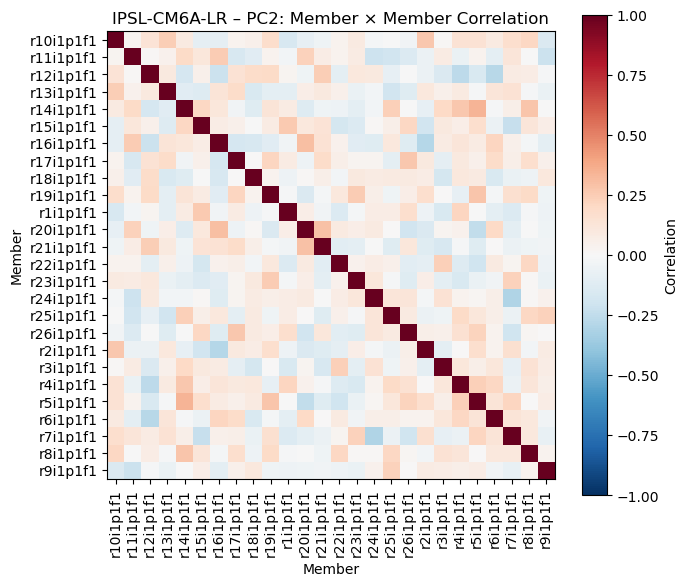

      Saved: /data/users/frekle/EOF/EOF_diagnostics/IPSL-CM6A-LR_PC_member_correlation_PC2.png
   → Computing Member × Member correlation matrix for PC3


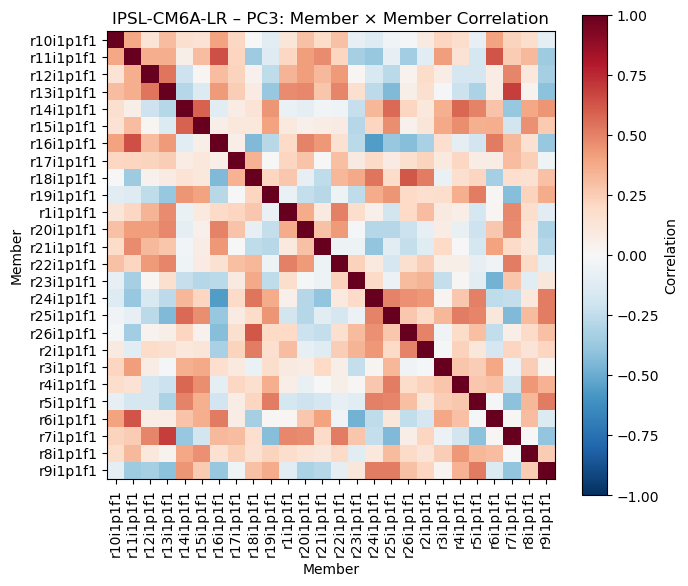

      Saved: /data/users/frekle/EOF/EOF_diagnostics/IPSL-CM6A-LR_PC_member_correlation_PC3.png
   → Creating Time × Mode PC amplitude heatmap (|PC|)


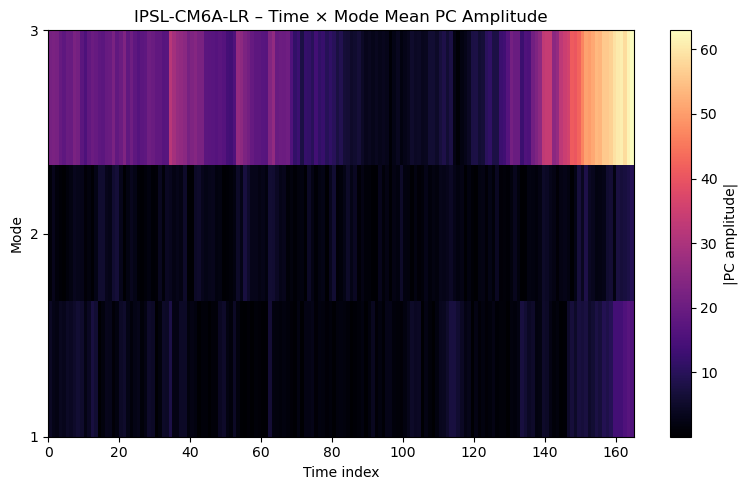

      Saved: /data/users/frekle/EOF/EOF_diagnostics/IPSL-CM6A-LR_PC_time_mode_heatmap.png

🎉 All diagnostics complete successfully!



In [1]:
#!/usr/bin/env python3
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================
MODELS = ["EC-Earth3", "CESM2", "IPSL-CM6A-LR"]
VAR = "thetao"
EOF_DIR = "/data/projects/nckf/frekle/EOF_results"
OUT_DIR = "/data/users/frekle/EOF/EOF_diagnostics"
os.makedirs(OUT_DIR, exist_ok=True)

# Number of leading modes to analyze
NMODES = 50          # analyze PCs 1–50
PLOT_MODES = 3       # plot PC1–PC3


# ============================================================
# Helper: Convert CESM cftime → numpy datetime
# ============================================================
def convert_time(ds):
    if not np.issubdtype(ds["time"].dtype, np.datetime64):
        try:
            return ds.indexes["time"].to_datetimeindex()
        except Exception:
            return ds["time"].dt.strftime("%Y-%m-%d").astype("datetime64[ns]")
    return ds["time"].values


# ============================================================
# Correct MODE × MODE correlation function
# ============================================================
def mode_mode_corr(PCs):
    """
    PCs: (member, time, mode)
    Returns (mode, mode) correlation matrix.
    """
    nmembers, nt, nmodes = PCs.shape
    corr = np.zeros((nmodes, nmodes))

    for i in range(nmodes):
        for j in range(nmodes):
            a = PCs[:, :, i].reshape(-1)
            b = PCs[:, :, j].reshape(-1)
            mask = np.isfinite(a) & np.isfinite(b)
            if mask.sum() > 3:
                corr[i, j] = np.corrcoef(a[mask], b[mask])[0, 1]
            else:
                corr[i, j] = np.nan
    return corr


# ============================================================
# MEMBER × MEMBER correlation helper
# ============================================================
def corr_matrix(mat):
    return np.corrcoef(mat, rowvar=False)


# ============================================================
# MAIN LOOP
# ============================================================
for model in MODELS:

    print(f"\n📘 Running diagnostics for {model}")

    # Load combined EOF file
    f = f"{EOF_DIR}/{model}/combined/EOF_combined_{VAR}_with_time.nc"
    ds = xr.open_dataset(f)

    PC = ds["PC"]  # (member, time, mode)
    time_np = convert_time(ds)

    nmembers = PC.sizes["member"]
    nt = PC.sizes["time"]
    nmodes_total = PC.sizes["mode"]

    PC_sel = PC.isel(mode=slice(0, NMODES))  # first N modes


    # ============================================================
    # A) CORRECT MODE × MODE CORRELATION MATRIX
    # ============================================================
    print("   → Computing correct Mode × Mode correlation matrix")

    C = mode_mode_corr(PC_sel.values)  # (NMODES × NMODES)

    plt.figure(figsize=(7, 6))
    plt.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(label="Correlation")
    plt.title(f"{model} – Mode × Mode PC Correlation")
    plt.xlabel("Mode")
    plt.ylabel("Mode")
    plt.xticks(np.arange(NMODES), np.arange(1, NMODES + 1))
    plt.yticks(np.arange(NMODES), np.arange(1, NMODES + 1))
    plt.tight_layout()

    out = f"{OUT_DIR}/{model}_PC_mode_correlation.png"
    # plt.savefig(out, dpi=150)
    plt.show()
    print(f"      Saved: {out}")


    # ============================================================
    # B) MEMBER × MEMBER CORRELATION (PC1–PC3)
    # ============================================================
    for m in range(PLOT_MODES):
        print(f"   → Computing Member × Member correlation matrix for PC{m+1}")

        pc_m = PC.isel(mode=m)  # (member, time)
        mat_m = pc_m.values.T   # shape: (time, member)
        C_mem = corr_matrix(mat_m)

        plt.figure(figsize=(7, 6))
        plt.imshow(C_mem, cmap="RdBu_r", vmin=-1, vmax=1)
        plt.colorbar(label="Correlation")
        plt.title(f"{model} – PC{m+1}: Member × Member Correlation")
        plt.xlabel("Member")
        plt.ylabel("Member")

        ticks = np.arange(nmembers)
        plt.xticks(ticks, ds["member"].values, rotation=90)
        plt.yticks(ticks, ds["member"].values)

        plt.tight_layout()

        out = f"{OUT_DIR}/{model}_PC_member_correlation_PC{m+1}.png"
        # plt.savefig(out, dpi=150)
        plt.show()
        print(f"      Saved: {out}")


    # ============================================================
    # C) TIME × MODE PC-AMPlITUDE HEATMAP
    # ============================================================
    print("   → Creating Time × Mode PC amplitude heatmap (|PC|)")

    PC_mean = PC.mean("member")
    PC_abs = np.abs(PC_mean.isel(mode=slice(0, PLOT_MODES)))

    plt.figure(figsize=(8, 5))
    plt.imshow(
        PC_abs.T,
        aspect='auto',
        cmap="magma",
        interpolation="nearest",
        extent=[0, nt, 1, PLOT_MODES]
    )

    plt.colorbar(label="|PC amplitude|")
    plt.title(f"{model} – Time × Mode Mean PC Amplitude")
    plt.xlabel("Time index")
    plt.ylabel("Mode")
    plt.yticks(np.arange(1, PLOT_MODES + 1))
    plt.tight_layout()

    out = f"{OUT_DIR}/{model}_PC_time_mode_heatmap.png"
    # plt.savefig(out, dpi=150)
    plt.show()
    print(f"      Saved: {out}")

print("\n🎉 All diagnostics complete successfully!\n")
